# Tanzania Food Demand and Nutritional Adequacy

This notebook estimates a demand system and discusses the landscape of the nutritional diet and its adequacy using household food expenditure data from Tanzania (2019–20 and 2020–21 survey waves). We then go on to simulate policies such as price subsidies, income transfers, and food fortification to analyze their potential effects. We build a policy recommendation from the best simulations following a policy cost analysis.

In [1]:
# Cell 1 — Environment setup (run once per session)
import subprocess
import sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'CFEDemands', '--quiet'])

0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cfe import Regression
import cfe

### Data [A]

The data is stored in a local Excel file (`Tanzania.xlsx`) with the following sheets:

- **Household Characteristics** — one row per household-wave, with demographic columns (household members by age/sex group and log household size).
- **Food Expenditures (2019-20)** and **Food Expenditures (2020-21)** — long-format records of household food expenditures, one row per household–food pair.

All sheets share the index columns `i` (household ID), `t` (survey wave), and `m` (market/region).

### Load raw sheets

In [3]:
DATA_FILE = 'Tanzania.xlsx'

# Household characteristics (filter to the two survey waves that have expenditure data)
d_raw = pd.read_excel(DATA_FILE, sheet_name='Household Characteristics')

# Food expenditures — two survey waves loaded separately and concatenated
x_raw_2019 = pd.read_excel(DATA_FILE, sheet_name='Food Expenditures (2019-20)')
x_raw_2020 = pd.read_excel(DATA_FILE, sheet_name='Food Expenditures (2020-21)')
x_raw = pd.concat([x_raw_2019, x_raw_2020], ignore_index=True)

print(f"Household characteristics rows : {len(d_raw):,}")
print(f"Food expenditure records       : {len(x_raw):,}")
print(f"Unique foods                   : {x_raw['j'].nunique()}")
print(f"Survey waves                   : {sorted(x_raw['t'].unique())}")

Household characteristics rows : 22,433
Food expenditure records       : 21,309
Unique foods                   : 59
Survey waves                   : ['2019-20', '2020-21']


### Household characteristics dataframe (d)
Missing values in demographic columns are treated as zero (no members of that age/sex group).

In [4]:
# Keep only waves that have matching expenditure data
WAVES = ['2019-20', '2020-21']
d = d_raw[d_raw['t'].isin(WAVES)].copy()

# Consistency string dtypes across columns
for col in ['i', 't', 'm']:
    d[col] = d[col].astype(str)

d.columns.name = 'k'
d.set_index(['i', 't', 'm'], inplace=True)
d = d.fillna(0) 

print(f"d shape: {d.shape}")
d.head()

d shape: (5893, 15)


,,k,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize
i,t,m,,,,,,,,,,,,,,,
0001-001-001,2019-20,Mainland Rural,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.693147
0001-001-003,2019-20,Mainland Rural,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.000000
0001-001-004,2019-20,Dar Es Salaam,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.000000
0001-004-001,2019-20,Mainland Rural,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1.098612
0001-004-002,2019-20,Mainland Other Urban,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0.000000


### Log-expenditure dataframe (y)

In [5]:
# Consistent string dtypes
for col in ['i', 't', 'm']:
    x_raw[col] = x_raw[col].astype(str)

# One column per food item
x = x_raw.pivot_table(
    index=['i', 't', 'm'],
    columns='j',
    values='Expenditure',
    aggfunc='sum'
)
x = x.replace(0, np.nan)  # Replace zeros with missing before taking logs
y = np.log(x)

print(f"y shape (households × foods): {y.shape}")
y.head()

y shape (households × foods): (1516, 59)


,,j,Beef,Bottled Beer,Bread,"Buns, Cakes And Biscuits","Butter, Etc.",Cassava Dry/Flour,Cassava Fresh,Chicken,Citrus Fruits,Coconuts,...,Sugarcane,Sweet Potatoes,Sweets,Tea (dry),Vegetables (fresh),Vegetables (preserved),Wheat Flour,Wild Birds & Insects,Wine & Spirits,Yams/Cocoyams
i,t,m,,,,,,,,,,,,,,,,,,,,,
0001-001-001,2019-20,Mainland Rural,NaN,NaN,NaN,NaN,NaN,NaN,7.313220,9.249561,NaN,NaN,...,NaN,NaN,NaN,4.787492,7.901007,NaN,NaN,NaN,NaN,NaN
0001-001-003,2019-20,Mainland Rural,8.006368,NaN,NaN,NaN,NaN,NaN,7.052937,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.540356,NaN,NaN,NaN,NaN,NaN
0001-001-004,2019-20,Dar Es Salaam,NaN,NaN,NaN,7.302496,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,6.273551,NaN,5.298317,7.042003,NaN,NaN,NaN,NaN,NaN
0001-004-001,2019-20,Mainland Rural,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7.531910,NaN,5.347108,7.150701,NaN,NaN,NaN,NaN,NaN
0001-004-002,2019-20,Mainland Other Urban,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.139101,NaN,NaN,NaN,NaN,NaN


### Re-format for regression

In [6]:
y = y.stack().dropna()
d = d.stack().dropna()

# Verify index structure
assert y.index.names == ['i', 't', 'm', 'j'], f"Unexpected y index: {y.index.names}"
assert d.index.names == ['i', 't', 'm', 'k'], f"Unexpected d index: {d.index.names}"

print(f"y observations : {len(y):,}")
print(f"d observations : {len(d):,}")

y observations : 21,309
d observations : 88,395


## Fit Regression Model

In [7]:
result = Regression(y=y, d=d)

In [8]:
result.predicted_expenditures()

i             t        m                     j                       
0001-001-001  2019-20  Mainland Rural        Beef                        6225.450559
                                             Bread                       1885.505572
                                             Buns, Cakes And Biscuits    1717.544391
                                             Cassava Fresh               2016.274266
                                             Chicken                     8141.135094
                                                                            ...     
9808-001-99   2020-21  Mainland Other Urban  Sugar                       2853.439504
                                             Sweet Potatoes              2360.359148
                                             Tea (dry)                    509.822159
                                             Vegetables (fresh)          2227.879537
                                             Wheat Flour                 2232.52

This regression model is **VERY IMPORTANT** for our future policy simulations. The predicted expenditure values here are used for the simulations.

### Predicted vs. actual log expenditures plot

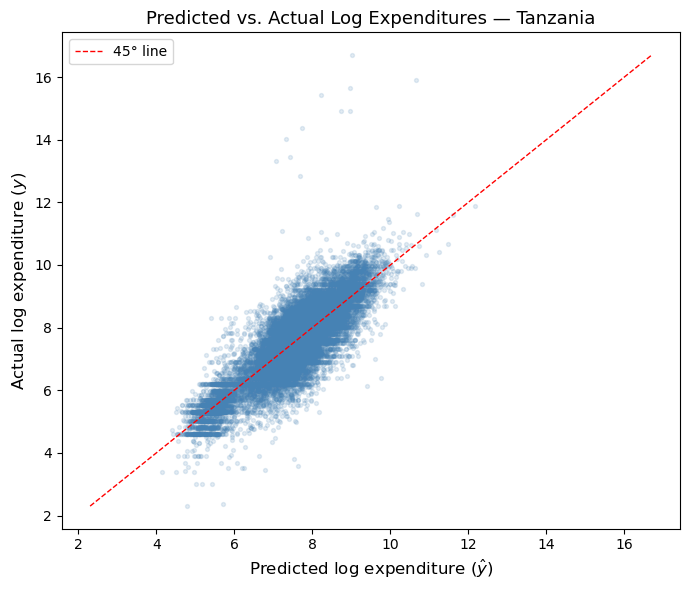

In [10]:
%matplotlib inline

df_fit = pd.DataFrame({
    'y'   : y,
    'yhat': result.get_predicted_log_expenditures()
})

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_fit['yhat'], df_fit['y'], alpha=0.15, s=8, color='steelblue')

# 45-degree reference line
lims = [df_fit[['y', 'yhat']].min().min(), df_fit[['y', 'yhat']].max().max()]
ax.plot(lims, lims, 'r--', linewidth=1, label='45° line')

ax.set_xlabel('Predicted log expenditure ($\\hat{y}$)', fontsize=12)
ax.set_ylabel('Actual log expenditure ($y$)', fontsize=12)
ax.set_title('Predicted vs. Actual Log Expenditures — Tanzania', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

This graph shows only in-sample fit so it doesn't really help us that much. The predicted expenditures however, will be very important for the future policy similuations.

## 4. Demand System [A]

### Frisch elasticities

The coefficients represent how income-elastic each food is. Higher values mean that a good's expenditure share rises more with total expenditure (it is more of a "luxury" within the food budget). Lower values indicates necessities that are always in demand regardless of price.

In [11]:
result.get_beta().sort_values()

j
Other Spices                0.085157
Fish (dried)                0.097858
Maize (flour)               0.163674
Salt                        0.219309
Chicken                     0.228003
Eggs                        0.302643
Bread                       0.346234
Cooking Oil                 0.346325
Rice (husked)               0.355506
Macaroni, Spaghetti         0.359340
Sugar                       0.363795
Pulses                      0.380210
Tea (dry)                   0.382893
Beef                        0.394625
Wheat Flour                 0.395246
Coconuts                    0.460999
Buns, Cakes And Biscuits    0.491180
Soft drinks                 0.491544
Irish Potatoes              0.491682
Milk (fresh)                0.514590
Fish (fresh)                0.519063
Vegetables (fresh)          0.528931
Cassava Fresh               0.582213
Sweet Potatoes              0.627395
Plantains                   0.668549
Leafy Greens                0.696915
Other Fruits                1.047823

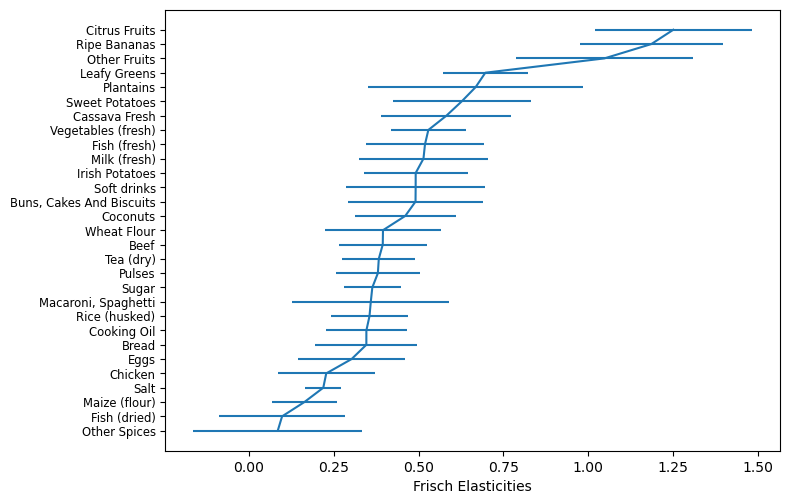

In [12]:
result.graph_beta()
plt.show()

As you can see, the important staple foods that are crucial for survival are those in the bottom left of the graph with low elasticities: households need these goods no matter what.

On the opposite end of the graph, we see foods like citrus and other fruits which tend to be more expensive. Since these have higher Frisch elasticities, these are the first to go when income fluctuates and are often crowded out by the cheaper staple foods.

### 4.2 Household composition effects

These numbers summarize how household demographic composition shifts demand for each food, based on total expenditure. Each row is a food; each column is a demographic characteristic.

In [13]:
result.gamma

k,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize,Constant
j,,,,,,,,,,,,,,,,
Beef,0.077682,-0.005968,0.111223,-0.013025,-0.192215,-0.109427,0.005910,0.061885,0.004780,0.036174,0.161237,0.151777,0.195287,0.127008,0.230110,8.757647
Bread,-0.144494,-0.106851,-0.013777,0.148933,0.132345,0.148128,-0.048996,0.088761,0.002687,0.100339,0.229477,0.060044,0.103132,0.295171,0.069250,7.709530
"Buns, Cakes And Biscuits",0.010819,-0.036685,-0.028856,-0.078656,0.087289,0.020987,0.065805,0.226198,-0.045866,-0.002440,0.033185,-0.064457,0.077756,-0.037615,0.397207,7.433694
Cassava Fresh,0.026137,0.062127,-0.000151,0.019185,0.070276,0.133597,0.071796,-0.072334,0.096153,-0.030905,0.012677,-0.031762,0.055274,0.217517,0.290560,7.510538
Chicken,0.031111,-0.132517,0.080621,0.091843,-0.079714,0.096516,-0.255527,-0.074955,-0.156359,0.004110,-0.095286,0.001454,-0.005707,0.034354,0.455818,9.049572
Citrus Fruits,-0.270057,-0.083495,-0.253770,0.044515,0.045555,-0.095496,0.075231,-0.019145,-0.074248,-0.113014,-0.084554,-0.124245,-0.254391,0.130596,0.576627,6.905943
Coconuts,-0.081598,-0.101330,-0.007152,0.000079,-0.028668,0.004202,-0.072938,0.018634,-0.005096,0.008348,-0.034155,-0.036708,0.108692,0.113382,0.440262,7.847034
Cooking Oil,-0.072479,-0.025707,-0.134748,-0.048658,-0.025759,-0.022279,0.068460,0.029011,-0.013321,0.158009,0.122801,0.144997,-0.028088,0.019905,0.269062,7.413332
Eggs,-0.190926,0.018887,0.118880,0.034417,-0.112722,0.174081,-0.055745,0.059651,0.030172,0.170285,0.192240,0.084080,-0.035207,0.125922,0.133956,7.422005


Here is the summarized household composition effects of demand, showing elasticities for each food based on age/sex group, also including a column for the effect of household size.

A few interesting trends stand out:
- Household size seems to be dominant driver in elasticity changes, having a much larger mean effect than any one age/sex group. This effect difference varies greatly between foods however, with the data suggesting that larger households tend to concentrate spending on staples rather than convenience foods.

- Older women (51+) show the strongest positive demographic effect on traditional staple foods, likely reflecting their role as the primary food decision-makers and a preference for traditional dietary patterns.

- Young children tend to suppress protein-rich and nutrient-dense food which is concerning.

- Teenage girls have the strongest positive demographic effect for most processed and convenience foods which is also concerning.

There seems to be systemic nutritional tensions between the people making food-decisions (working age men and older women) and the people who are most nutritionally vulnerable.

## Nutritional Content of Different Foods [B]

### Identify foods and nutrient mapping

In [14]:
import re
import time
import requests
import pandas as pd
import numpy as np

# Foods from the final CFE model
FOODS = [
    'Beef', 'Bread', 'Buns, Cakes And Biscuits', 'Cassava Fresh', 'Chicken',
    'Citrus Fruits', 'Coconuts', 'Cooking Oil', 'Eggs', 'Fish (dried)',
    'Fish (fresh)', 'Irish Potatoes', 'Leafy Greens', 'Macaroni, Spaghetti',
    'Maize (flour)', 'Milk (fresh)', 'Other Fruits', 'Other Spices',
    'Plantains', 'Pulses', 'Rice (husked)', 'Ripe Bananas', 'Salt',
    'Soft drinks', 'Sugar', 'Sweet Potatoes', 'Tea (dry)',
    'Vegetables (fresh)', 'Wheat Flour',
]

# Mapping nutrients to ids 
NUTRIENT_MAP = {
    'Energy':                          1008,  # kcal
    'Protein':                         1003,  # g
    'Fiber, total dietary':            1079,  # g
    'Folate, DFE':                     1190,  # µg
    'Calcium, Ca':                     1087,  # mg
    'Carbohydrate, by difference':     1005,  # g
    'Iron, Fe':                        1089,  # mg
    'Magnesium, Mg':                   1090,  # mg
    'Niacin':                          1167,  # mg
    'Phosphorus, P':                   1091,  # mg
    'Potassium, K':                    1092,  # mg
    'Riboflavin':                      1166,  # mg
    'Thiamin':                         1165,  # mg
    'Vitamin A, RAE':                  1106,  # µg
    'Vitamin B-12':                    1178,  # µg
    'Vitamin B-6':                     1175,  # µg
    'Vitamin C, total ascorbic acid':  1162,  # mg
    'Vitamin E (alpha-tocopherol)':    1109,  # mg
    'Vitamin K (phylloquinone)':       1185,  # µg
    'Zinc, Zn':                        1095,  # mg
}

FDC_API_KEY    = 'uOgTaIqGwW8Of1b6UcucKDg1yWcBt01FPea0hqDT'
FDC_SEARCH_URL = 'https://api.nal.usda.gov/fdc/v1/foods/search'
FDC_FOOD_URL   = 'https://api.nal.usda.gov/fdc/v1/food/{fdcId}'

### Find FDC IDs

In [15]:
# making searching the fdc database more accurate/efficient
SEARCH_OVERRIDES = {
    'Beef':                    'beef ground raw',
    'Bread':                   'bread white commercially prepared',
    'Buns, Cakes And Biscuits':'biscuits plain prepared from recipe',
    'Cassava Fresh':           'cassava raw',
    'Chicken':                 'chicken broilers or fryers meat only raw',
    'Citrus Fruits':           'oranges raw navels',
    'Coconuts':                'coconut meat raw',
    'Cooking Oil':             'oil vegetable sunflower',
    'Eggs':                    'egg whole raw fresh',
    'Fish (dried)':            'fish tilapia dried',
    'Fish (fresh)':            'fish tilapia raw',
    'Irish Potatoes':          'potatoes white flesh and skin raw',
    'Leafy Greens':            'spinach raw',
    'Macaroni, Spaghetti':     'pasta dry unenriched',
    'Maize (flour)':           'corn flour whole-grain yellow',
    'Milk (fresh)':            'milk whole 3.25% milkfat without added vitamin A and D',
    'Other Fruits':            'mixed fruit raw',
    'Other Spices':            'spices mixed',
    'Plantains':               'plantains green raw',
    'Pulses':                  'beans black mature seeds raw',
    'Rice (husked)':           'rice white long-grain regular raw unenriched',
    'Ripe Bananas':            'bananas raw',
    'Salt':                    'salt table',
    'Soft drinks':             'beverages carbonated cola regular',
    'Sugar':                   'sugars granulated',
    'Sweet Potatoes':          'sweet potato raw unprepared',
    'Tea (dry)':               'beverages tea black brewed prepared with tap water',
    'Vegetables (fresh)':      'tomatoes red ripe raw year round average',
    'Wheat Flour':             'wheat flour whole-grain',
}

def search_fdc(food_name, api_key, preferred_types=('Foundation', 'SR Legacy')):
    """Return the fdcId of the best FDC match for a food name, skipping any
    IDs that return 404 from the individual food endpoint."""
    query = SEARCH_OVERRIDES.get(food_name, food_name)
    # Strip characters the FDC API rejects and collapse whitespace (had issues with this causing errors eralier)
    query = re.sub(r'[(),]', ' ', query)
    query = re.sub(r'\s+', ' ', query).strip()

    params = {
        'query':    query,
        'dataType': ','.join(preferred_types),
        'pageSize': 5,
        'api_key':  api_key,
    }
    resp = requests.get(FDC_SEARCH_URL, params=params)
    resp.raise_for_status()
    candidates = resp.json().get('foods', [])

    for candidate in candidates:
        fdc_id = candidate['fdcId']
        check = requests.get(FDC_FOOD_URL.format(fdcId=fdc_id), params={'api_key': api_key})
        if check.status_code == 200:
            return fdc_id, candidate['description']
        elif check.status_code == 404:
            print(f"  [{food_name}] fdcId {fdc_id} returned 404, trying next candidate...")
            time.sleep(0.2)
            continue
        else:
            check.raise_for_status()

    return None, None 

# Search for all 29 foods
food_ids = {}
print(f"{'Food':<30} {'fdcId':>8}  Description")
print('-' * 80)
for food in FOODS:
    fdc_id, desc = search_fdc(food, FDC_API_KEY)
    food_ids[food] = fdc_id
    print(f"{food:<30} {str(fdc_id):>8}  {desc}")
    time.sleep(0.2)

Food                              fdcId  Description
--------------------------------------------------------------------------------
Beef                             168608  Beef, grass-fed, ground, raw
Bread                            174925  Bread, white, commercially prepared, toasted
Buns, Cakes And Biscuits         172670  Biscuits, plain or buttermilk, prepared from recipe
Cassava Fresh                    169985  Cassava, raw
Chicken                          171052  Chicken, broilers or fryers, meat only, raw
  [Citrus Fruits] fdcId 746771 returned 404, trying next candidate...
Citrus Fruits                    169917  Oranges, raw, navels (Includes foods for USDA's Food Distribution Program)
Coconuts                         170169  Nuts, coconut meat, raw
Cooking Oil                     1750349  Oil, sunflower
Eggs                             171287  Egg, whole, raw, fresh
Fish (dried)                     175176  Fish, tilapia, raw
Fish (fresh)                     175176  Fish, 

In [16]:
# final food_df with nutrients
def fetch_nutrients(fdc_id, nutrient_ids, api_key):
    """Return a dict {nutrient_name: value_per_100g} for the requested nutrient IDs."""
    url = FDC_FOOD_URL.format(fdcId=fdc_id)
    resp = requests.get(url, params={'api_key': api_key})
    resp.raise_for_status()
    data = resp.json()

    # Build a lookup: nutrient_id -> value
    id_to_value = {}
    for n in data.get('foodNutrients', []):
        nid = (n.get('nutrient') or {}).get('id') or n.get('nutrientId')
        val = n.get('amount') or n.get('value')
        if nid and val is not None:
            id_to_value[nid] = val

    return {name: id_to_value.get(nid) for name, nid in nutrient_ids.items()}

# Fetch nutrient data for every food
records = []
for food, fdc_id in food_ids.items():
    if fdc_id is None:
        print(f"WARNING: no FDC match found for '{food}', skipping.")
        continue
    nutrients = fetch_nutrients(fdc_id, NUTRIENT_MAP, FDC_API_KEY)
    nutrients['food']  = food
    nutrients['fdcId'] = fdc_id
    records.append(nutrients)
    time.sleep(0.2) # had issues with rate of requests

food_df = pd.DataFrame(records).set_index('food')
print(food_df.shape)
food_df

(29, 21)


,Energy,Protein,"Fiber, total dietary","Folate, DFE","Calcium, Ca","Carbohydrate, by difference","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P",...,Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn",fdcId
food,,,,,,,,,,,,,,,,,,,,,
Beef,198.0,19.42,NaN,6.0,12.0,NaN,1.99,19.0,4.818,175.0,...,0.154,0.049,NaN,1.97,0.355,NaN,0.35,1.100,4.55,168608
Bread,290.0,9.00,2.9,160.0,119.0,54.50,3.33,26.0,3.926,103.0,...,0.337,0.415,NaN,0.02,0.063,NaN,0.24,3.400,0.68,174925
"Buns, Cakes And Biscuits",353.0,7.00,1.5,95.0,235.0,44.60,2.90,18.0,2.949,164.0,...,0.310,0.356,NaN,0.08,0.035,0.2,NaN,NaN,0.54,172670
Cassava Fresh,160.0,1.36,1.8,27.0,16.0,38.06,0.27,21.0,0.854,27.0,...,0.048,0.087,1.0,NaN,0.088,20.6,0.19,1.900,0.34,169985
Chicken,119.0,21.39,NaN,7.0,12.0,NaN,0.89,25.0,8.239,173.0,...,0.142,0.073,16.0,0.37,0.430,2.3,0.21,1.800,1.54,171052
Citrus Fruits,49.0,0.91,2.2,34.0,43.0,12.54,0.13,11.0,0.425,23.0,...,0.051,0.068,12.0,NaN,0.079,59.1,0.15,NaN,0.08,169917
Coconuts,354.0,3.33,9.0,26.0,14.0,15.23,2.43,32.0,0.540,113.0,...,0.020,0.066,NaN,NaN,0.054,3.3,0.24,0.200,1.10,170169
Cooking Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.48,6.925,NaN,1750349
Eggs,143.0,12.56,NaN,47.0,56.0,0.72,1.75,12.0,0.075,198.0,...,0.457,0.040,160.0,0.89,0.170,NaN,1.05,0.300,1.29,171287


In [17]:
# Diet minimums
rdi = pd.read_csv('diet_minimums.csv', index_col=0)
rdi = rdi.set_index('Nutrition').drop(columns='Source')

# Show for F 19-30 and M 19-30
rdi_adult = rdi[['F 19-30', 'M 19-30']].apply(pd.to_numeric, errors='coerce').mean(axis=1)
rdi_adult.name = 'RDI_adult_avg'

# Nutrients per 100g
nutrient_cols  = list(NUTRIENT_MAP.keys())
food_nutrients = food_df[nutrient_cols].apply(pd.to_numeric, errors='coerce')

# % of adult RDI provided per 100g of each food
coverage_pct = food_nutrients.div(rdi_adult, axis=1) * 100
coverage_pct.columns.name = 'nutrient'
coverage_pct.index.name   = 'food'

print("% of adult RDI provided per 100g (for selected nutrients)")
display_cols = ['Energy', 'Protein', 'Iron, Fe', 'Calcium, Ca',
                'Vitamin A, RAE', 'Vitamin C, total ascorbic acid', 'Zinc, Zn']
print(coverage_pct[display_cols].round(1).to_string())

% of adult RDI provided per 100g (for selected nutrients)
nutrient                  Energy  Protein  Iron, Fe  Calcium, Ca  Vitamin A, RAE  Vitamin C, total ascorbic acid  Zinc, Zn
food                                                                                                                      
Beef                         9.0     38.1      15.3          1.2             NaN                             NaN      47.9
Bread                       13.2     17.6      25.6         11.9             NaN                             NaN       7.2
Buns, Cakes And Biscuits    16.0     13.7      22.3         23.5             NaN                             0.2       5.7
Cassava Fresh                7.3      2.7       2.1          1.6             0.1                            25.0       3.6
Chicken                      5.4     41.9       6.8          1.2             2.0                             2.8      16.2
Citrus Fruits                2.2      1.8       1.0          4.3             1.5 

Nutrients with WEAK coverage (no single food provides ≥20% RDI per 100g):
nutrient
Energy    17.5

Nutrients with GOOD coverage (≥20% RDI from at least one food):
nutrient
Vitamin K (phylloquinone)         459.9
Vitamin E (alpha-tocopherol)      456.5
Iron, Fe                          151.6
Folate, DFE                       111.0
Vitamin B-12                       82.1
Thiamin                            78.3
Carbohydrate, by difference        76.6
Vitamin C, total ascorbic acid     71.6
Calcium, Ca                        68.2
Vitamin A, RAE                     58.6
Niacin                             54.9
Fiber, total dietary               50.3
Phosphorus, P                      50.3
Magnesium, Mg                      48.2
Zinc, Zn                           47.9
Protein                            42.4
Riboflavin                         38.1
Vitamin B-6                        33.1
Potassium, K                       31.6


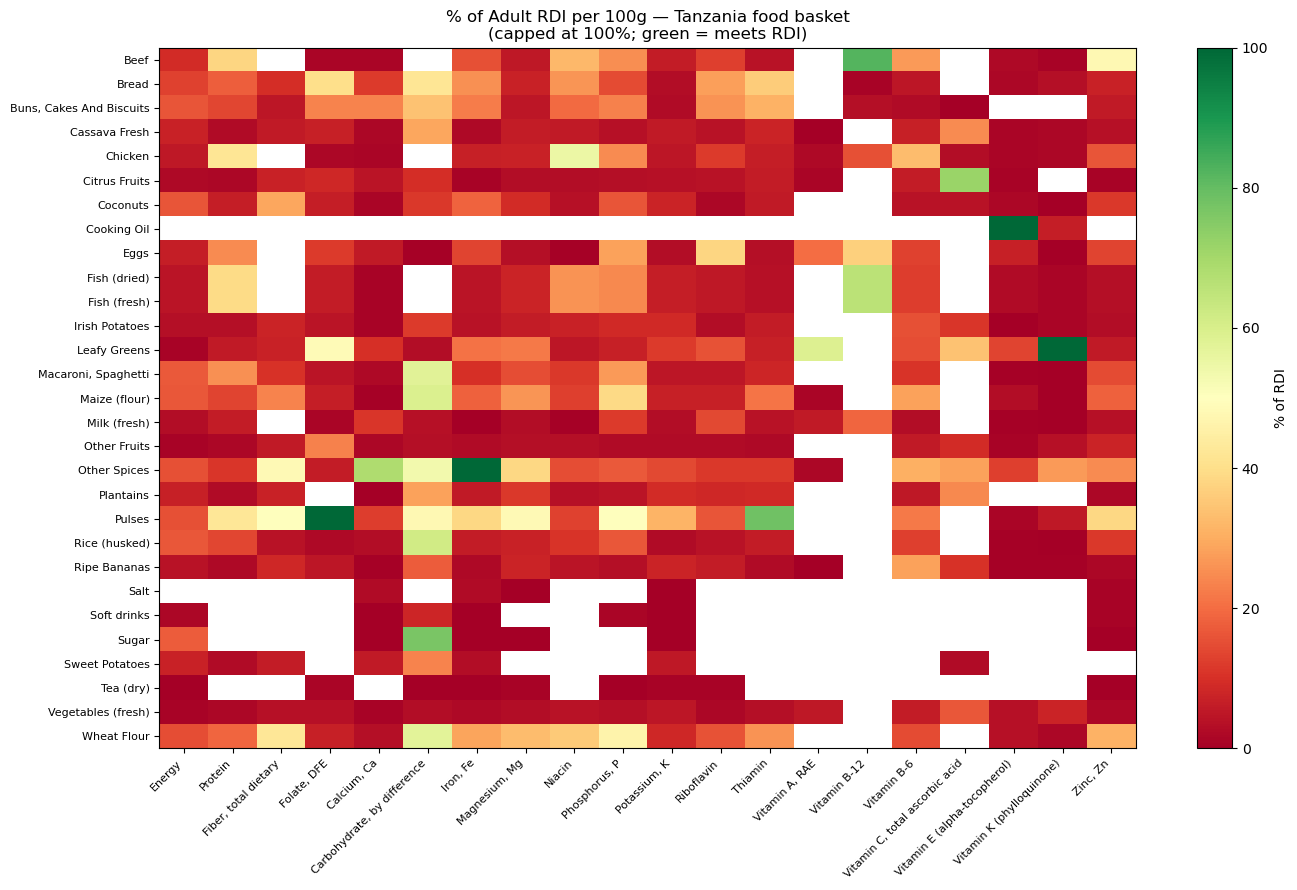

In [18]:
# nutritional gaps and heatmap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Best single food for each nutrient across the whole basket
max_coverage = coverage_pct.max(axis=0)

gaps   = max_coverage[max_coverage <  20].sort_values()
strong = max_coverage[max_coverage >= 20].sort_values(ascending=False)

print("Nutrients with WEAK coverage (no single food provides ≥20% RDI per 100g):")
print(gaps.round(1).to_string())
print("\nNutrients with GOOD coverage (≥20% RDI from at least one food):")
print(strong.round(1).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(14, 9))
data = coverage_pct[nutrient_cols].clip(upper=100)

im = ax.imshow(data.values, aspect='auto', cmap='RdYlGn',
               norm=mcolors.Normalize(vmin=0, vmax=100))

ax.set_xticks(range(len(nutrient_cols)))
ax.set_xticklabels(nutrient_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(data)))
ax.set_yticklabels(data.index, fontsize=8)
ax.set_title(
    '% of Adult RDI per 100g — Tanzania food basket\n(capped at 100%; green = meets RDI)',
    fontsize=12
)
plt.colorbar(im, ax=ax, label='% of RDI')
plt.tight_layout()
plt.savefig('tanzania_nutrient_coverage.png', dpi=150)
plt.show()

**Explanation:** While this heatmap is important to understand the landscape of foods and their nutritional content, it can be misleading. First of all, the 29 foods that survived to this point in the model are chosen because they have enough observations to be relevant, so more nutrient-dense foods could be excluded. Secondly, no singly food is meant to cover then entire RDI for a nutrient...a diet is supposed to include many of these foods.

## Nutritional Adequacy at the household level [B]

In [19]:
# Load prices w/both waves, take prices
p1 = pd.read_excel('Tanzania.xlsx', sheet_name='Food Prices (2019-20)')
p2 = pd.read_excel('Tanzania.xlsx', sheet_name='Food Prices (2020-21)')
prices = pd.concat([p1, p2], ignore_index=True)

# Convert prices to per gram
prices['price_per_g'] = prices['Price'] / 1000
price_map = (prices.groupby(['t', 'm', 'j'])['price_per_g']
                   .median()
                   .reset_index()
                   .set_index(['t', 'm', 'j'])['price_per_g'])

# Load food expenditures
x1 = pd.read_excel('Tanzania.xlsx', sheet_name='Food Expenditures (2019-20)')
x2 = pd.read_excel('Tanzania.xlsx', sheet_name='Food Expenditures (2020-21)')
x_long = pd.concat([x1, x2], ignore_index=True)
for col in ['i', 't', 'm']:
    x_long[col] = x_long[col].astype(str)

# Keep only the 29 foods in the model (data consistency)
x_long = x_long[x_long['j'].isin(FOODS)]

x_long = x_long.join(price_map, on=['t', 'm', 'j'])

# If price is missing, use median
national_price = prices.groupby('j')['price_per_g'].median()
x_long['price_per_g'] = x_long['price_per_g'].fillna(x_long['j'].map(national_price))

# Grams purchased per recall period
x_long['grams'] = x_long['Expenditure'] / x_long['price_per_g']

# The survey recall period is 7 days —> convert to grams/day
RECALL_DAYS = 7
x_long['grams_per_day'] = x_long['grams'] / RECALL_DAYS

### Daily nutrient intake per household

In [20]:
# Nutrient content per gram (food_df is per 100g)
nutrients_per_g = food_nutrients / 100

# Map nutrient content onto expenditure rows
nutrient_cols = list(NUTRIENT_MAP.keys())
for col in nutrient_cols:
    x_long[col] = x_long['j'].map(nutrients_per_g[col])

# Nutrient intake per food per day = grams_per_day * nutrient_per_gram
intake_cols = []
for col in nutrient_cols:
    intake_col = f'intake_{col}'
    x_long[intake_col] = x_long['grams_per_day'] * x_long[col]
    intake_cols.append(intake_col)

# Get total daily nutrient intake per household
hh_intake = (x_long.groupby(['i', 't', 'm'])[intake_cols]
                    .sum()
                    .rename(columns=lambda c: c.replace('intake_', '')))

print(f"Households with valid nutrient intake estimates: {len(hh_intake):,}")
hh_intake.head()

Households with valid nutrient intake estimates: 1,514


,,,Energy,Protein,"Fiber, total dietary","Folate, DFE","Calcium, Ca","Carbohydrate, by difference","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P","Potassium, K",Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn"
i,t,m,,,,,,,,,,,,,,,,,,,,
0001-001-001,2019-20,Mainland Rural,948.405485,55.039814,12.124776,519.066562,299.678951,166.504246,8.747810,296.061429,21.894047,576.957298,2857.665136,0.854640,0.639033,1067.113853,0.752185,1.683452,149.335656,29.917000,1010.634461,5.583126
0001-001-003,2019-20,Mainland Rural,1429.940668,61.317765,31.642736,783.618444,334.966837,260.674145,14.585679,487.338917,14.071520,1067.276263,3804.304737,0.861088,1.469207,841.532276,2.388210,1.750132,111.690977,29.530997,816.109557,10.824810
0001-001-004,2019-20,Dar Es Salaam,3902.832514,102.197695,57.225594,823.313470,655.066306,788.453060,21.811605,736.824094,21.300160,2338.074757,4665.526021,1.304956,2.700385,148.460048,2.580328,2.608212,33.681383,52.509963,25.384733,16.325350
0001-004-001,2019-20,Mainland Rural,4310.557553,109.114612,40.973798,284.250493,1034.420178,854.892000,16.081576,579.033847,19.340951,2179.460930,4063.657954,1.555924,1.495223,527.382082,3.592084,2.476382,33.191372,32.545339,243.453958,14.382199
0001-004-002,2019-20,Mainland Other Urban,32.284887,4.490080,1.809731,129.612136,69.786808,3.676331,1.901212,56.720283,1.130743,59.498352,471.532366,0.132559,0.067025,308.527936,0.187521,0.170107,22.527110,29.405601,307.885182,0.444872


### Household specific RDI targets

In [21]:
# Reload household characteristics (filtered to our two waves)
d_raw = pd.read_excel('Tanzania.xlsx', sheet_name='Household Characteristics')
d_hh = d_raw[d_raw['t'].isin(['2019-20', '2020-21'])].copy()
for col in ['i', 't', 'm']:
    d_hh[col] = d_hh[col].astype(str)
d_hh = d_hh.set_index(['i', 't', 'm']).fillna(0)


rdi = pd.read_csv('diet_minimums.csv', index_col=0)
rdi = rdi.set_index('Nutrition').drop(columns='Source')
rdi = rdi.apply(pd.to_numeric, errors='coerce')

# Map demographic columns in d_hh to RDI columns
DEMO_TO_RDI = {
    'Males 00-03':   'C 1-3',
    'Females 00-03': 'C 1-3',
    'Males 04-08':   'M 4-8',
    'Females 04-08': 'F 4-8',
    'Males 09-13':   'M 9-13',
    'Females 09-13': 'F 9-13',
    'Males 14-18':   'M 14-18',
    'Females 14-18': 'F 14-18',
    'Males 19-30':   'M 19-30',
    'Females 19-30': 'F 19-30',
    'Males 31-50':   'M 31-50',
    'Females 31-50': 'F 31-50',
    'Males 51-99':   'M 51+',
    'Females 51-99': 'F 51+',
}

# For each household, RDI_hh = sum over members of (n_members_in_group * RDI_for_group)
demo_cols = [c for c in DEMO_TO_RDI if c in d_hh.columns]

rdi_hh = pd.DataFrame(index=d_hh.index, columns=nutrient_cols, dtype=float)
rdi_hh[:] = 0.0

for demo_col in demo_cols:
    rdi_col = DEMO_TO_RDI[demo_col]
    if rdi_col not in rdi.columns:
        continue
    # n_members in this group for each household (shape: n_households)
    n_members = d_hh[demo_col]
    # RDI for this group for each nutrient (shape: n_nutrients)
    rdi_for_group = rdi[rdi_col]
    # Outer product: each household's contribution from this demographic group
    contribution = pd.DataFrame(
        np.outer(n_members.values, rdi_for_group.values),
        index=n_members.index,
        columns=rdi_for_group.index
    )
    rdi_hh = rdi_hh.add(contribution.reindex(columns=nutrient_cols), fill_value=0)

rdi_hh = rdi_hh.apply(pd.to_numeric)
print(f"Household RDI targets computed for {len(rdi_hh):,} households")
rdi_hh.head()

Household RDI targets computed for 5,893 households


,,,Energy,Protein,"Fiber, total dietary","Folate, DFE","Calcium, Ca","Carbohydrate, by difference","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P","Potassium, K",Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn"
i,t,m,,,,,,,,,,,,,,,,,,,,
0001-001-001,2019-20,Mainland Rural,3600.0,102.0,50.4,800.0,2200.0,260.0,16.0,740.0,30.0,1400.0,9400.0,2.4,2.3,1600.0,4.8,3.2,165.0,30.0,210.0,19.0
0001-001-003,2019-20,Mainland Rural,2200.0,56.0,30.8,400.0,1000.0,130.0,8.0,420.0,16.0,700.0,4700.0,1.3,1.2,900.0,2.4,1.3,90.0,15.0,120.0,11.0
0001-001-004,2019-20,Dar Es Salaam,2400.0,56.0,33.6,400.0,1000.0,130.0,8.0,400.0,16.0,700.0,4700.0,1.3,1.2,900.0,2.4,1.3,90.0,15.0,120.0,11.0
0001-004-001,2019-20,Mainland Rural,5400.0,115.0,75.6,950.0,2700.0,390.0,33.0,790.0,36.0,1860.0,12400.0,2.9,2.8,1900.0,5.7,3.1,180.0,36.0,240.0,22.0
0001-004-002,2019-20,Mainland Other Urban,2000.0,46.0,28.0,400.0,1000.0,130.0,18.0,310.0,14.0,700.0,4700.0,1.1,1.1,700.0,2.4,1.3,75.0,15.0,90.0,8.0


### Compare intake to RDI and evaluate adequacy

In [22]:
# Align households with expenditure and demographic data
common_idx = hh_intake.index.intersection(rdi_hh.index)
intake_aligned = hh_intake.loc[common_idx, nutrient_cols]
rdi_aligned    = rdi_hh.loc[common_idx, nutrient_cols]

print(f"Households in joint sample: {len(common_idx):,}")

# Adequacy ratio: intake / household RDI (>1 means household meets its target)
adequacy = intake_aligned / rdi_aligned

# Proportion of households meeting RDI for each nutrient
meets_rdi = (adequacy >= 1.0).mean() * 100  # percent

print("% of households meeting household RDI")
print(meets_rdi.sort_values().round(1).to_string())

Households in joint sample: 1,514
% of households meeting household RDI
Calcium, Ca                        2.2
Vitamin A, RAE                    12.0
Potassium, K                      13.0
Vitamin B-12                      17.2
Riboflavin                        22.9
Vitamin C, total ascorbic acid    30.8
Niacin                            34.7
Vitamin E (alpha-tocopherol)      43.4
Energy                            43.9
Zinc, Zn                          46.7
Iron, Fe                          49.5
Folate, DFE                       55.2
Protein                           56.5
Fiber, total dietary              56.6
Thiamin                           58.4
Vitamin B-6                       61.9
Magnesium, Mg                     63.1
Vitamin K (phylloquinone)         64.1
Phosphorus, P                     67.3
Carbohydrate, by difference       91.5


Adequacy summary
                                pct_meeting_RDI  median_adequacy  pct_below_half_RDI
Calcium, Ca                                 2.2             0.22                87.0
Vitamin A, RAE                             12.0             0.29                69.0
Potassium, K                               13.0             0.52                47.6
Vitamin B-12                               17.2             0.35                60.6
Riboflavin                                 22.9             0.60                38.4
Vitamin C, total ascorbic acid             30.8             0.60                42.4
Niacin                                     34.7             0.81                21.4
Vitamin E (alpha-tocopherol)               43.4             0.89                26.0
Energy                                     43.9             0.92                14.9
Zinc, Zn                                   46.7             0.95                15.6
Iron, Fe                                   49.5 

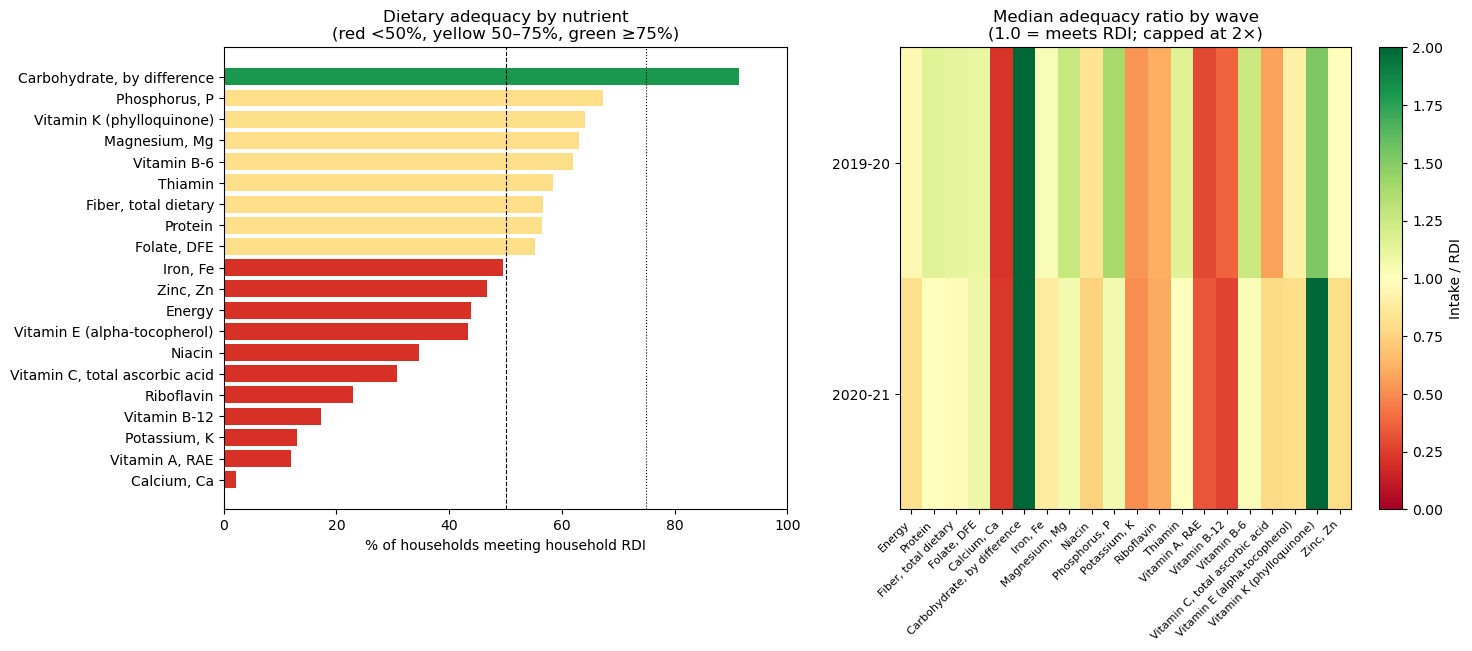

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: bar chart of % households meeting RDI
meets_sorted = meets_rdi.sort_values()
colors = ['#d73027' if v < 50 else '#fee08b' if v < 75 else '#1a9850'
          for v in meets_sorted]
axes[0].barh(meets_sorted.index, meets_sorted.values, color=colors)
axes[0].axvline(50, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(75, color='black', linewidth=0.8, linestyle=':')
axes[0].set_xlabel('% of households meeting household RDI')
axes[0].set_title('Dietary adequacy by nutrient\n(red <50%, yellow 50–75%, green ≥75%)')
axes[0].set_xlim(0, 100)

# Right: heatmap of median adequacy ratio by nutrient and survey wave
adequacy_wave = adequacy.reset_index()
med_by_wave = (adequacy_wave.groupby('t')[nutrient_cols]
                             .median()
                             .clip(upper=2))

im = axes[1].imshow(med_by_wave.values, aspect='auto', cmap='RdYlGn',
                    norm=mcolors.Normalize(vmin=0, vmax=2))
axes[1].set_xticks(range(len(nutrient_cols)))
axes[1].set_xticklabels(nutrient_cols, rotation=45, ha='right', fontsize=8)
axes[1].set_yticks(range(len(med_by_wave)))
axes[1].set_yticklabels(med_by_wave.index)
axes[1].set_title('Median adequacy ratio by wave\n(1.0 = meets RDI; capped at 2×)')
plt.colorbar(im, ax=axes[1], label='Intake / RDI')

# Summary table
summary = pd.DataFrame({
    'pct_meeting_RDI':    meets_rdi.round(1),
    'median_adequacy':    adequacy.median().round(2),
    'pct_below_half_RDI': ((adequacy < 0.5).mean() * 100).round(1),
}).sort_values('pct_meeting_RDI')

print("Adequacy summary")
print(summary.to_string())

Here we see the % of Households that actually meet the recommended dietary intakes that we outlined earlier. The graph shows the percentage of households meeting the household RDI on the x-axis with the specific nutrient on the y-axis. The exact values are shown in the table in the top right.

The heatmap shows not just whether households meet requirements, but how far they are from them. An interesting trend appears in that several RDIs move from slightly green to yellowish from the first wave to the second. You would expect nutritional outcomes to increase over time, not regress. This is very likely due to the COVID-19 pandemic. From 2019-2020, COVID had not yet reached Tanzania; but in the subsequent years, the pandemic had a huge impact: disrupting supply chains, the tourism industry, and dramatically lowering income and purchasing power.

### Nutrient Deficiencies
Calcium is a catastrophic deficiency and should be our main focus. Only 2.2% of households meet this RDI with 87% below half their requirement (nothing else comes close). The food basket represented by our 29 foods has no adequate calcium source other than milk (which has a higher Frisch elasticity of 0.52 so it is not within budget for many households).

Vitamin A is the next most severe deficiency. Only 12% meet the RDI, with 69% below half of the RDI. Sweet potatoes and leafy greens are the main sources of Vitamin A in the food basket but both have higher Frisch elasticities (0.63 and 0.70 respectively).

Potassium and B-12 also represent severe deficiences with only 13% of householdes meeting the potassium RDI and 17.2% meeting B-12. The B-12 deficiency is likely explained by the low animal food consumption levels which also drives the zinc and iron deficiencies. 

Riboflavin, Vitamin C, Niacin, Vitamin E, and Energy make up the middle tier where roughly 23–44% of households meet requirements. Energy itself is only reahced by 43.9% of households so generally, caloric needs are not being met.

### Policy Goals

Goal 1: Calcium – Reduce the number of households below 50% RDI from 87% to around 65%. Realistically, we could fortify a widely-consumed staple food such as maize flour. Income transfers won’t work on their own.

Goal 2: Vitamin A – Reduce the number of households below 75% RDI from ~88% to below 65%. Fortification of cooking oil is the best intervention and is already in place but compliance is the issue. Income transfers/growth could also help because leafy greens and sweet potatoes are available but have higher Frisch elasticities.

Goal 3: Vitamin B-12 & Potassium – While goals 1 and 2 should be the biggest focus, these are also worth addressing. B-12 requires animal-source food subsidies or direct supplementation. Potassium can be addressed through increased fruit and vegetable consumption which again can be increased through income transfers and subsidies/incentives.

Iron and Zinc not primary targets. Caloric adequacy (energy) is mixed, median household almost reaches RDI but only 43.9% totally meet it. Simply addressing nutrient deficiencies cannot be totally separate from overall food access.

## Policy Simulations

**NOTE**: Policy simulations are conducted using model-predicted rather than actual expenditures for two reasons. First, actual survey expenditures reflect a single 7-day recall period, meaning many households record zero purchases for foods they regularly consume but happened not to buy that week. Using these zeros as a baseline would understate true consumption and make policies appear more effective than they are by artificially depressing the starting expenditure point. Second, and more fundamentally, consistency requires that the baseline and the counterfactual be generated by the same model — applying demand elasticities estimated from the CFE regression to actual expenditures would mix two different data-generating processes. Predicted expenditures represent each household's expected demand given their income, demographics, and market prices, which is the correct baseline against which to measure a structural change in those same variables. Policy impacts are therefore reported as percentage-point changes relative to the predicted baseline rather than as absolute adequacy rates, which should be taken from the observed-expenditure analysis.

In [25]:
# Cell — Shared constants (run before any simulation chunks)

TARGET_NUTRIENTS = [
    'Vitamin A, RAE',
    'Calcium, Ca',
    'Iron, Fe',
    'Zinc, Zn',
    'Vitamin B-12',
    'Potassium, K',
]

FOODS = [
    'Beef', 'Bread', 'Buns, Cakes And Biscuits', 'Cassava Fresh', 'Chicken',
    'Citrus Fruits', 'Coconuts', 'Cooking Oil', 'Eggs', 'Fish (dried)',
    'Fish (fresh)', 'Irish Potatoes', 'Leafy Greens', 'Macaroni, Spaghetti',
    'Maize (flour)', 'Milk (fresh)', 'Other Fruits', 'Other Spices',
    'Plantains', 'Pulses', 'Rice (husked)', 'Ripe Bananas', 'Salt',
    'Soft drinks', 'Sugar', 'Sweet Potatoes', 'Tea (dry)',
    'Vegetables (fresh)', 'Wheat Flour',
]

nutrient_per_100g = {
    'Beef':                    {'Vitamin A, RAE': 0,    'Calcium, Ca': 12,  'Iron, Fe': 2.6,  'Zinc, Zn': 4.8,  'Vitamin B-12': 2.60,  'Potassium, K': 318},
    'Bread':                   {'Vitamin A, RAE': 0,    'Calcium, Ca': 151, 'Iron, Fe': 3.6,  'Zinc, Zn': 0.7,  'Vitamin B-12': 0.01,  'Potassium, K': 115},
    'Buns, Cakes And Biscuits':{'Vitamin A, RAE': 15,   'Calcium, Ca': 141, 'Iron, Fe': 1.8,  'Zinc, Zn': 0.5,  'Vitamin B-12': 0.10,  'Potassium, K': 120},
    'Cassava Fresh':           {'Vitamin A, RAE': 1,    'Calcium, Ca': 16,  'Iron, Fe': 0.3,  'Zinc, Zn': 0.3,  'Vitamin B-12': 0.00,  'Potassium, K': 271},
    'Chicken':                 {'Vitamin A, RAE': 9,    'Calcium, Ca': 11,  'Iron, Fe': 0.9,  'Zinc, Zn': 1.3,  'Vitamin B-12': 0.31,  'Potassium, K': 223},
    'Citrus Fruits':           {'Vitamin A, RAE': 11,   'Calcium, Ca': 40,  'Iron, Fe': 0.1,  'Zinc, Zn': 0.1,  'Vitamin B-12': 0.00,  'Potassium, K': 181},
    'Coconuts':                {'Vitamin A, RAE': 0,    'Calcium, Ca': 14,  'Iron, Fe': 2.4,  'Zinc, Zn': 1.1,  'Vitamin B-12': 0.00,  'Potassium, K': 356},
    'Cooking Oil':             {'Vitamin A, RAE': 0,    'Calcium, Ca': 0,   'Iron, Fe': 0.0,  'Zinc, Zn': 0.0,  'Vitamin B-12': 0.00,  'Potassium, K': 0},
    'Eggs':                    {'Vitamin A, RAE': 160,  'Calcium, Ca': 56,  'Iron, Fe': 1.8,  'Zinc, Zn': 1.3,  'Vitamin B-12': 0.89,  'Potassium, K': 138},
    'Fish (dried)':            {'Vitamin A, RAE': 15,   'Calcium, Ca': 170, 'Iron, Fe': 2.9,  'Zinc, Zn': 1.5,  'Vitamin B-12': 2.80,  'Potassium, K': 340},
    'Fish (fresh)':            {'Vitamin A, RAE': 8,    'Calcium, Ca': 14,  'Iron, Fe': 0.4,  'Zinc, Zn': 0.4,  'Vitamin B-12': 1.58,  'Potassium, K': 302},
    'Irish Potatoes':          {'Vitamin A, RAE': 0,    'Calcium, Ca': 9,   'Iron, Fe': 0.5,  'Zinc, Zn': 0.3,  'Vitamin B-12': 0.00,  'Potassium, K': 421},
    'Leafy Greens':            {'Vitamin A, RAE': 469,  'Calcium, Ca': 99,  'Iron, Fe': 2.7,  'Zinc, Zn': 0.5,  'Vitamin B-12': 0.00,  'Potassium, K': 558},
    'Macaroni, Spaghetti':     {'Vitamin A, RAE': 0,    'Calcium, Ca': 7,   'Iron, Fe': 0.5,  'Zinc, Zn': 0.5,  'Vitamin B-12': 0.00,  'Potassium, K': 44},
    'Maize (flour)':           {'Vitamin A, RAE': 0,    'Calcium, Ca': 4,   'Iron, Fe': 1.0,  'Zinc, Zn': 0.6,  'Vitamin B-12': 0.00,  'Potassium, K': 142},
    'Milk (fresh)':            {'Vitamin A, RAE': 46,   'Calcium, Ca': 113, 'Iron, Fe': 0.0,  'Zinc, Zn': 0.4,  'Vitamin B-12': 0.45,  'Potassium, K': 150},
    'Other Fruits':            {'Vitamin A, RAE': 20,   'Calcium, Ca': 15,  'Iron, Fe': 0.4,  'Zinc, Zn': 0.1,  'Vitamin B-12': 0.00,  'Potassium, K': 200},
    'Other Spices':            {'Vitamin A, RAE': 5,    'Calcium, Ca': 50,  'Iron, Fe': 1.0,  'Zinc, Zn': 0.5,  'Vitamin B-12': 0.00,  'Potassium, K': 100},
    'Plantains':               {'Vitamin A, RAE': 56,   'Calcium, Ca': 3,   'Iron, Fe': 0.6,  'Zinc, Zn': 0.1,  'Vitamin B-12': 0.00,  'Potassium, K': 499},
    'Pulses':                  {'Vitamin A, RAE': 0,    'Calcium, Ca': 123, 'Iron, Fe': 5.0,  'Zinc, Zn': 3.7,  'Vitamin B-12': 0.00,  'Potassium, K': 1483},
    'Rice (husked)':           {'Vitamin A, RAE': 0,    'Calcium, Ca': 9,   'Iron, Fe': 0.3,  'Zinc, Zn': 0.5,  'Vitamin B-12': 0.00,  'Potassium, K': 35},
    'Ripe Bananas':            {'Vitamin A, RAE': 3,    'Calcium, Ca': 5,   'Iron, Fe': 0.3,  'Zinc, Zn': 0.2,  'Vitamin B-12': 0.00,  'Potassium, K': 358},
    'Salt':                    {'Vitamin A, RAE': 0,    'Calcium, Ca': 24,  'Iron, Fe': 0.3,  'Zinc, Zn': 0.1,  'Vitamin B-12': 0.00,  'Potassium, K': 8},
    'Soft drinks':             {'Vitamin A, RAE': 0,    'Calcium, Ca': 3,   'Iron, Fe': 0.0,  'Zinc, Zn': 0.0,  'Vitamin B-12': 0.00,  'Potassium, K': 2},
    'Sugar':                   {'Vitamin A, RAE': 0,    'Calcium, Ca': 1,   'Iron, Fe': 0.1,  'Zinc, Zn': 0.0,  'Vitamin B-12': 0.00,  'Potassium, K': 2},
    'Sweet Potatoes':          {'Vitamin A, RAE': 961,  'Calcium, Ca': 30,  'Iron, Fe': 0.6,  'Zinc, Zn': 0.3,  'Vitamin B-12': 0.00,  'Potassium, K': 337},
    'Tea (dry)':               {'Vitamin A, RAE': 0,    'Calcium, Ca': 0,   'Iron, Fe': 0.0,  'Zinc, Zn': 0.0,  'Vitamin B-12': 0.00,  'Potassium, K': 37},
    'Vegetables (fresh)':      {'Vitamin A, RAE': 42,   'Calcium, Ca': 10,  'Iron, Fe': 0.3,  'Zinc, Zn': 0.2,  'Vitamin B-12': 0.00,  'Potassium, K': 237},
    'Wheat Flour':             {'Vitamin A, RAE': 0,    'Calcium, Ca': 15,  'Iron, Fe': 3.9,  'Zinc, Zn': 2.6,  'Vitamin B-12': 0.00,  'Potassium, K': 107},
}

nutrients_df = pd.DataFrame(nutrient_per_100g).T

# ── Prices ────────────────────────────────────────────────────────────────────
p1 = pd.read_excel('Tanzania.xlsx', sheet_name='Food Prices (2019-20)')
p2 = pd.read_excel('Tanzania.xlsx', sheet_name='Food Prices (2020-21)')
prices = pd.concat([p1, p2], ignore_index=True)
prices['t'] = prices['t'].astype(str)
prices['m'] = prices['m'].astype(str)
prices['price_per_g'] = prices['Price'] / 1000
price_map      = prices.groupby(['t', 'm', 'j'])['price_per_g'].median()
national_price = prices.groupby('j')['price_per_g'].median()

# ── Household RDI targets ─────────────────────────────────────────────────────
rdi_raw = pd.read_csv('diet_minimums.csv', index_col=0)
rdi     = rdi_raw.set_index('Nutrition').drop(columns='Source').apply(pd.to_numeric, errors='coerce')

DEMO_TO_RDI = {
    'Males 00-03':   'C 1-3',  'Females 00-03': 'C 1-3',
    'Males 04-08':   'M 4-8',  'Females 04-08': 'F 4-8',
    'Males 09-13':   'M 9-13', 'Females 09-13': 'F 9-13',
    'Males 14-18':   'M 14-18','Females 14-18': 'F 14-18',
    'Males 19-30':   'M 19-30','Females 19-30': 'F 19-30',
    'Males 31-50':   'M 31-50','Females 31-50': 'F 31-50',
    'Males 51-99':   'M 51+',  'Females 51-99': 'F 51+',
}

d_hh = pd.read_excel('Tanzania.xlsx', sheet_name='Household Characteristics')
d_hh = d_hh[d_hh['t'].isin(['2019-20', '2020-21'])].copy()
for col in ['i', 't', 'm']:
    d_hh[col] = d_hh[col].astype(str)
d_hh = d_hh.set_index(['i', 't', 'm']).fillna(0)

rdi_hh = pd.DataFrame(0.0, index=d_hh.index, columns=TARGET_NUTRIENTS)
for demo_col, rdi_col in DEMO_TO_RDI.items():
    if demo_col not in d_hh.columns or rdi_col not in rdi.columns:
        continue
    for nut in TARGET_NUTRIENTS:
        if nut in rdi.index:
            rdi_hh[nut] += d_hh[demo_col] * rdi.loc[nut, rdi_col]

# ── pe_long: predicted expenditures in long format with prices attached ───────
# (requires result object from the demand estimation cells above)
pe = result.predicted_expenditures()
pe_long = pe.reset_index()
pe_long.columns = ['i', 't', 'm', 'j', 'expenditure']
pe_long = pe_long[pe_long['j'].isin(FOODS)].copy()
pe_long = pe_long.join(price_map, on=['t', 'm', 'j'])
pe_long['price_per_g'] = pe_long['price_per_g'].fillna(pe_long['j'].map(national_price))

In [26]:
# Simulation baseline: use predicted expenditures from demand system
# This is the right baseline for counterfactuals because: it covers all foods for all households via the estimated demand curves, 
# it smooths over the recall-period zero problem in raw expenditure data, counterfactual changes are applied through the same model

pe = result.predicted_expenditures()  # TZS/week per household per food
beta = result.get_beta()              # Frisch elasticities
w = result.get_w()                 # log total expenditure index per household

# Reshape predicted expenditures into a wide dataframe (households x foods)
pe_wide = pe.unstack('j').reindex(columns=FOODS)

# Attach prices to convert expenditures -> grams/day
pe_long = pe.reset_index()
pe_long.columns = ['i','t','m','j','expenditure']
pe_long = pe_long[pe_long['j'].isin(FOODS)].copy()
pe_long = pe_long.join(price_map, on=['t','m','j'])
pe_long['price_per_g'] = pe_long['price_per_g'].fillna(pe_long['j'].map(national_price))
pe_long['grams_per_day'] = pe_long['expenditure'] / pe_long['price_per_g'] / 7

# Baseline nutrient intake per household per day
for nut in TARGET_NUTRIENTS:
    pe_long[nut] = pe_long['j'].map(nutrients_df[nut]) * pe_long['grams_per_day'] / 100

hh_intake_baseline = pe_long.groupby(['i','t','m'])[TARGET_NUTRIENTS].sum()

# Baseline adequacy ratios
common = hh_intake_baseline.index.intersection(rdi_hh.index)
baseline_adequacy = hh_intake_baseline.loc[common] / rdi_hh.loc[common]

def adequacy_summary(adequacy_df, label=''):
    """Print and return a summary Series of % meeting RDI per nutrient."""
    pct = (adequacy_df >= 1.0).mean() * 100
    if label:
        print(f"\n{'='*55}")
        print(f"  {label}")
        print(f"{'='*55}")
        for nut in TARGET_NUTRIENTS:
            print(f"  {nut:<25} {pct[nut]:5.1f}% meeting RDI")
    return pct

baseline_pct = adequacy_summary(baseline_adequacy, 'BASELINE')


  BASELINE
  Vitamin A, RAE             83.7% meeting RDI
  Calcium, Ca                11.4% meeting RDI
  Iron, Fe                   90.9% meeting RDI
  Zinc, Zn                   87.4% meeting RDI
  Vitamin B-12               89.7% meeting RDI
  Potassium, K               52.7% meeting RDI


In [28]:
def simulate(pe_long_in, nutrient_content=None, label='Simulation'):
    """
    Run a counterfactual and return adequacy rates.

    Parameters
    ----------
    pe_long_in : DataFrame
        Long-format predicted expenditures with columns
        [i, t, m, j, expenditure, price_per_g, grams_per_day].
        Pass a modified copy for each simulation.
    nutrient_content : dict or None
        Override nutrient content per 100g for specific foods.
        e.g. {'Cooking Oil': {'Vitamin A, RAE': 800}}
        If None, uses the original nutrients_df.
    label : str
        Label for printed output.

    Returns
    -------
    adequacy_df : DataFrame of adequacy ratios (households x nutrients)
    pct_meeting : Series of % households meeting RDI per nutrient
    """
    nut_df = nutrients_df.copy()
    if nutrient_content:
        for food, updates in nutrient_content.items():
            for nut, val in updates.items():
                nut_df.loc[food, nut] = val

    sim = pe_long_in.copy()
    sim['grams_per_day'] = sim['expenditure'] / sim['price_per_g'] / 7

    for nut in TARGET_NUTRIENTS:
        sim[nut] = sim['j'].map(nut_df[nut]) * sim['grams_per_day'] / 100

    hh_intake = sim.groupby(['i','t','m'])[TARGET_NUTRIENTS].sum()
    common_idx = hh_intake.index.intersection(rdi_hh.index)
    adequacy   = hh_intake.loc[common_idx] / rdi_hh.loc[common_idx]
    pct        = adequacy_summary(adequacy, label)
    return adequacy, pct

In [29]:
# Policy 1: Cash transfer equal to 20% of median weekly food expenditure 
# Mechanism: shifting w (log total expenditure) shifts log demand for each food
# by beta_j * delta_w. This is the core CFE demand response.
#
# We simulate three transfer sizes to show dose-response:
#   Small  = 10% income increase
#   Medium = 20% income increase  (headline policy)
#   Large  = 50% income increase

def apply_income_shock(pe_long_base, beta, delta_w_scalar):
    """
    Scale predicted expenditures by exp(beta_j * delta_w) for each food.
    delta_w_scalar is a single float applied uniformly to all households.
    """
    sim = pe_long_base.copy()
    scale = sim['j'].map(beta).apply(lambda b: np.exp(b * delta_w_scalar))
    sim['expenditure'] = sim['expenditure'] * scale
    return sim

transfer_sizes = {
    'Transfer +10%': np.log(1.10),
    'Transfer +20%': np.log(1.20),
    'Transfer +50%': np.log(1.50),
}

income_results = {'Baseline': baseline_pct}
for label, delta_w in transfer_sizes.items():
    sim_data = apply_income_shock(pe_long, beta, delta_w)
    _, pct = simulate(sim_data, label=label)
    income_results[label] = pct

# Summary table
income_summary = pd.DataFrame(income_results).T[TARGET_NUTRIENTS]
print("\n=== INCOME TRANSFER SUMMARY (% meeting RDI) ===")
print(income_summary.round(1).to_string())


  Transfer +10%
  Vitamin A, RAE             84.7% meeting RDI
  Calcium, Ca                13.0% meeting RDI
  Iron, Fe                   92.0% meeting RDI
  Zinc, Zn                   88.9% meeting RDI
  Vitamin B-12               90.5% meeting RDI
  Potassium, K               57.2% meeting RDI

  Transfer +20%
  Vitamin A, RAE             86.6% meeting RDI
  Calcium, Ca                14.9% meeting RDI
  Iron, Fe                   93.0% meeting RDI
  Zinc, Zn                   90.2% meeting RDI
  Vitamin B-12               91.7% meeting RDI
  Potassium, K               61.7% meeting RDI

  Transfer +50%
  Vitamin A, RAE             89.5% meeting RDI
  Calcium, Ca                19.2% meeting RDI
  Iron, Fe                   96.1% meeting RDI
  Zinc, Zn                   93.5% meeting RDI
  Vitamin B-12               93.6% meeting RDI
  Potassium, K               71.7% meeting RDI

=== INCOME TRANSFER SUMMARY (% meeting RDI) ===
               Vitamin A, RAE  Calcium, Ca  Iron, Fe  

In [30]:
# Policy 2: Price subsidy on the three highest Vitamin A and Calcium foods
# Mechanism: a subsidy reduces effective price_per_g, increasing grams_per_day
# for a given level of nominal expenditure.
# We assume own-price elasticity of -0.5 (conservative, mid-range for staples
# in Sub-Saharan Africa literature) to scale the expenditure response.
#
# Target foods chosen by nutrient density per TZS:
#   Vitamin A: Sweet Potatoes, Leafy Greens, Eggs
#   Calcium:   Dried Fish, Bread, Milk (fresh)

OWN_PRICE_ELASTICITY = -0.5  # assumed; note this as a limitation

def apply_price_subsidy(pe_long_base, price_map_base, subsidy_foods, subsidy_rate,
                        elasticity=OWN_PRICE_ELASTICITY):
    """
    Apply a price subsidy to specific foods.

    Parameters
    ----------
    subsidy_foods : list of food names to subsidise
    subsidy_rate  : fraction reduction in price (e.g. 0.30 = 30% cheaper)
    elasticity    : own-price elasticity (negative)
    """
    sim = pe_long_base.copy()
    # For subsidised foods: new price = old price * (1 - subsidy_rate)
    # Quantity response: delta_q/q = elasticity * delta_p/p = elasticity * (-subsidy_rate)
    # => new expenditure = old_exp * (1 - subsidy_rate) * (1 + |elasticity| * subsidy_rate)
    mask = sim['j'].isin(subsidy_foods)
    price_effect    = (1 - subsidy_rate)
    quantity_effect = (1 + abs(elasticity) * subsidy_rate)
    sim.loc[mask, 'price_per_g']  = sim.loc[mask, 'price_per_g'] * price_effect
    sim.loc[mask, 'expenditure']  = sim.loc[mask, 'expenditure'] * price_effect * quantity_effect
    return sim

# Vitamin A subsidy: 30% price reduction on sweet potatoes, leafy greens, eggs
vit_a_foods   = ['Sweet Potatoes', 'Leafy Greens', 'Eggs']
# Calcium subsidy: 30% price reduction on dried fish, bread, milk
calcium_foods = ['Fish (dried)', 'Bread', 'Milk (fresh)']
# Combined subsidy on all six foods
combined_foods = vit_a_foods + calcium_foods

subsidy_scenarios = {
    'Subsidy: Vit A foods 30%':   (vit_a_foods,   0.30),
    'Subsidy: Calcium foods 30%': (calcium_foods,  0.30),
    'Subsidy: All targets 30%':   (combined_foods, 0.30),
    'Subsidy: All targets 50%':   (combined_foods, 0.50),
}

subsidy_results = {'Baseline': baseline_pct}
for label, (foods, rate) in subsidy_scenarios.items():
    sim_data = apply_price_subsidy(pe_long, price_map, foods, rate)
    _, pct = simulate(sim_data, label=label)
    subsidy_results[label] = pct

subsidy_summary = pd.DataFrame(subsidy_results).T[TARGET_NUTRIENTS]
print("\n=== PRICE SUBSIDY SUMMARY (% meeting RDI) ===")
print(subsidy_summary.round(1).to_string())


  Subsidy: Vit A foods 30%
  Vitamin A, RAE             86.4% meeting RDI
  Calcium, Ca                12.7% meeting RDI
  Iron, Fe                   91.7% meeting RDI
  Zinc, Zn                   88.2% meeting RDI
  Vitamin B-12               90.1% meeting RDI
  Potassium, K               55.4% meeting RDI

  Subsidy: Calcium foods 30%
  Vitamin A, RAE             83.7% meeting RDI
  Calcium, Ca                12.8% meeting RDI
  Iron, Fe                   91.5% meeting RDI
  Zinc, Zn                   87.9% meeting RDI
  Vitamin B-12               91.2% meeting RDI
  Potassium, K               53.8% meeting RDI

  Subsidy: All targets 30%
  Vitamin A, RAE             86.6% meeting RDI
  Calcium, Ca                14.9% meeting RDI
  Iron, Fe                   92.1% meeting RDI
  Zinc, Zn                   88.6% meeting RDI
  Vitamin B-12               92.0% meeting RDI
  Potassium, K               55.9% meeting RDI

  Subsidy: All targets 50%
  Vitamin A, RAE             88.3% meeti

In [31]:
# Policy 3: Fortification
# Mechanism: fortification changes nutrient content per 100g without changing
# quantities purchased. No demand response — pure nutritional accounting.
# This is the correct model for a mandatory fortification program.
#
# Scenarios based on Tanzania's actual fortification program:
#   (a) Cooking oil: Vitamin A fortified to 750 µg RAE / 100g (WHO standard)
#   (b) Maize flour: fortified to 100 µg Vitamin A and 200mg Calcium / 100g
#       (realistic for double-fortified flour)
#   (c) Full compliance: both oil and maize at WHO standards

# Note: current Cooking Oil Vit A in fdc_df is ~0 (unfortified baseline)
# Tanzania standard for fortified oil: 750 µg RAE / 100g (edible oil standard)
# Maize flour standard: iron 60mg, Vit A 100µg, Calcium not typically fortified
# We use conservative estimates to avoid overstating impact

fortification_scenarios = {
    'Fortify: Oil (Vit A)': {
        'Cooking Oil': {'Vitamin A, RAE': 750}
    },
    'Fortify: Maize flour (Vit A + Ca)': {
        'Maize (flour)': {'Vitamin A, RAE': 100, 'Calcium, Ca': 200}
    },
    'Fortify: Full compliance (oil + maize)': {
        'Cooking Oil':  {'Vitamin A, RAE': 750},
        'Maize (flour)': {'Vitamin A, RAE': 100, 'Calcium, Ca': 200}
    },
    'Fortify: Full + Wheat flour (Ca)': {
        'Cooking Oil':   {'Vitamin A, RAE': 750},
        'Maize (flour)': {'Vitamin A, RAE': 100, 'Calcium, Ca': 200},
        'Wheat Flour':   {'Calcium, Ca': 200}
    },
}

fortification_results = {'Baseline': baseline_pct}
for label, nutrient_overrides in fortification_scenarios.items():
    # Quantities unchanged — pass original pe_long, only change nutrient content
    _, pct = simulate(pe_long, nutrient_content=nutrient_overrides, label=label)
    fortification_results[label] = pct

fortification_summary = pd.DataFrame(fortification_results).T[TARGET_NUTRIENTS]
print("\n=== FORTIFICATION SUMMARY (% meeting RDI) ===")
print(fortification_summary.round(1).to_string())


  Fortify: Oil (Vit A)
  Vitamin A, RAE             88.3% meeting RDI
  Calcium, Ca                11.4% meeting RDI
  Iron, Fe                   90.9% meeting RDI
  Zinc, Zn                   87.4% meeting RDI
  Vitamin B-12               89.7% meeting RDI
  Potassium, K               52.7% meeting RDI

  Fortify: Maize flour (Vit A + Ca)
  Vitamin A, RAE             90.2% meeting RDI
  Calcium, Ca                36.0% meeting RDI
  Iron, Fe                   90.9% meeting RDI
  Zinc, Zn                   87.4% meeting RDI
  Vitamin B-12               89.7% meeting RDI
  Potassium, K               52.7% meeting RDI

  Fortify: Full compliance (oil + maize)
  Vitamin A, RAE             93.2% meeting RDI
  Calcium, Ca                36.0% meeting RDI
  Iron, Fe                   90.9% meeting RDI
  Zinc, Zn                   87.4% meeting RDI
  Vitamin B-12               89.7% meeting RDI
  Potassium, K               52.7% meeting RDI

  Fortify: Full + Wheat flour (Ca)
  Vitamin A, RA

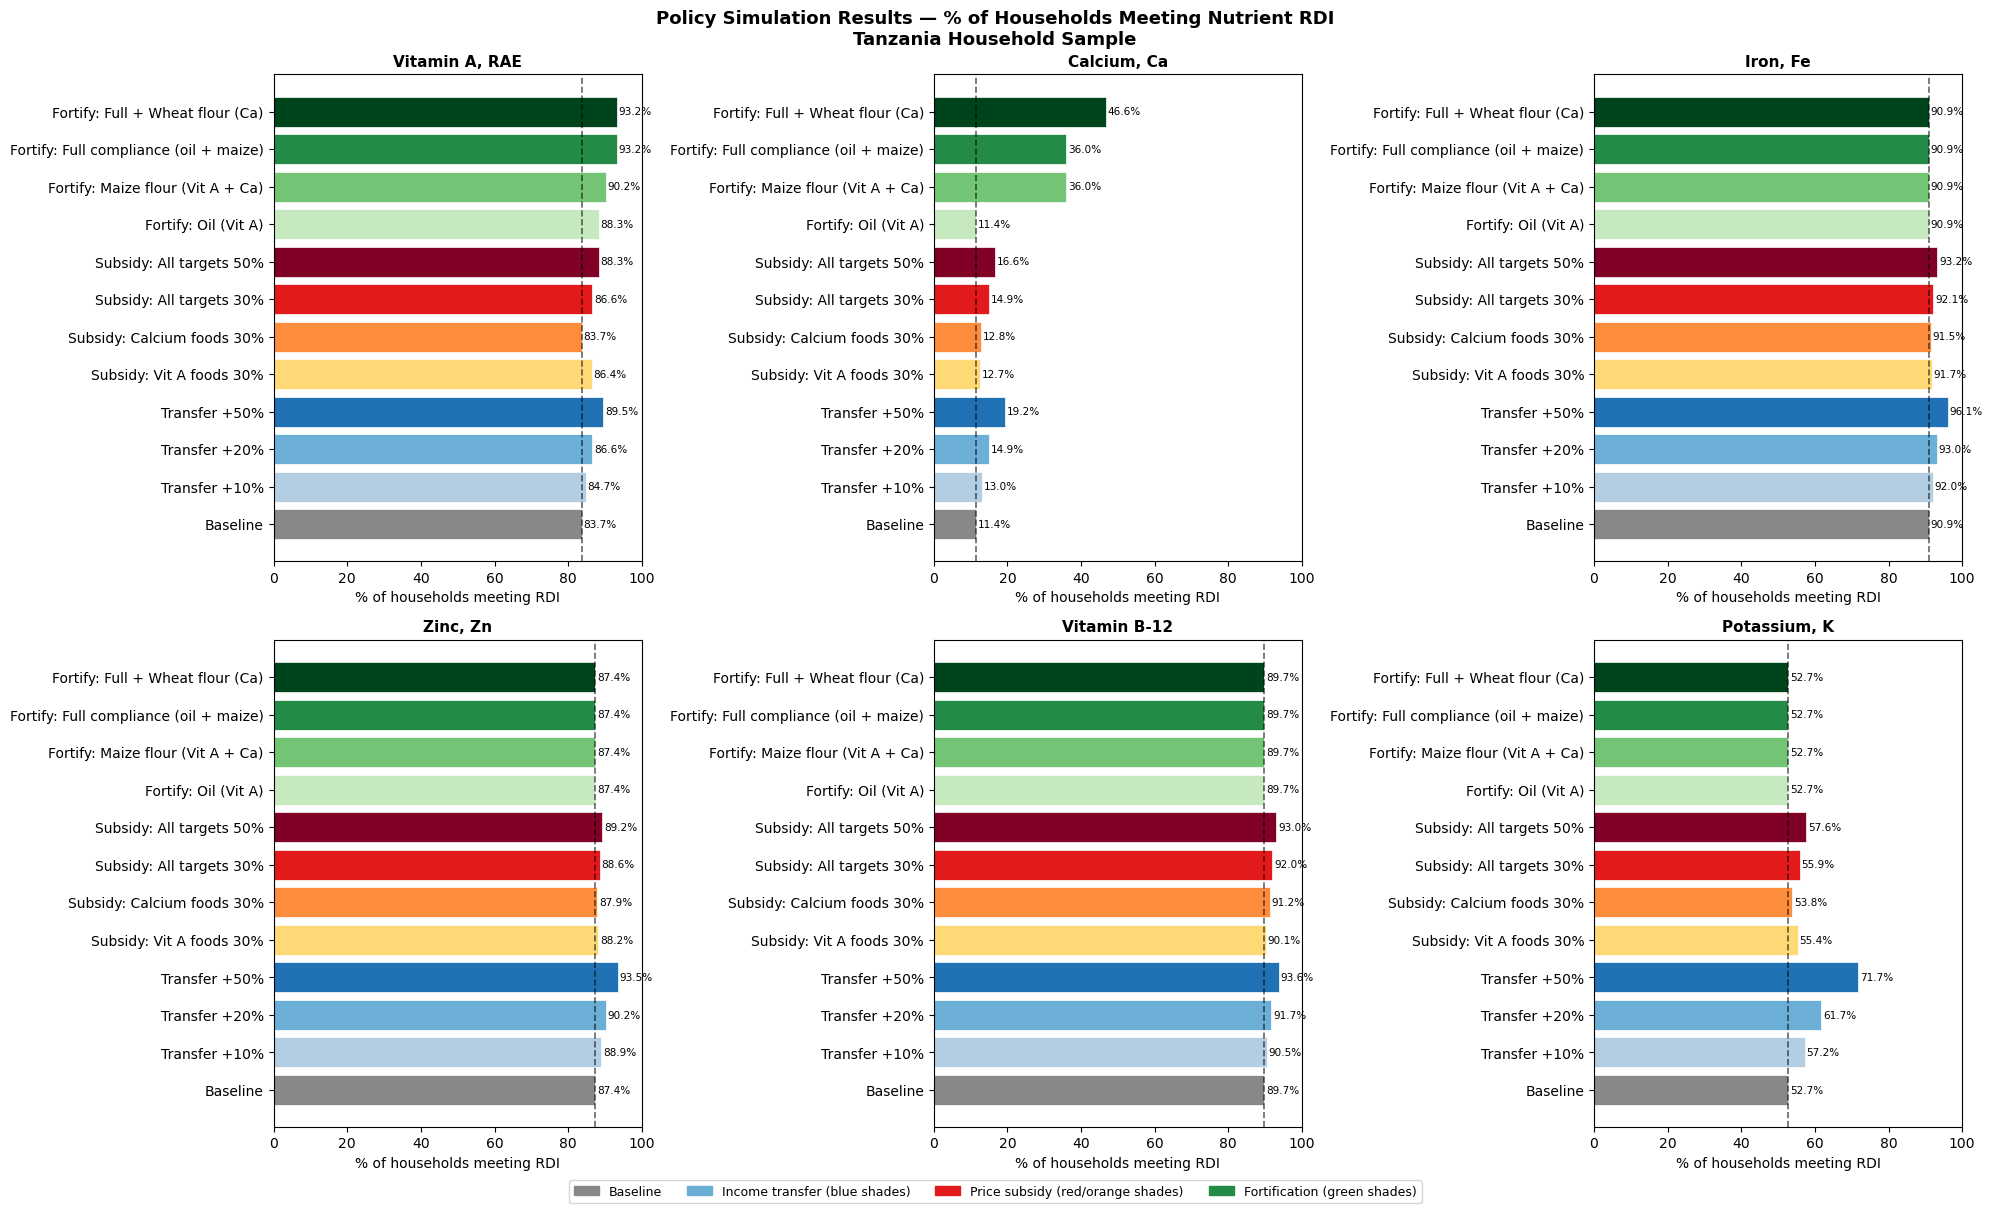

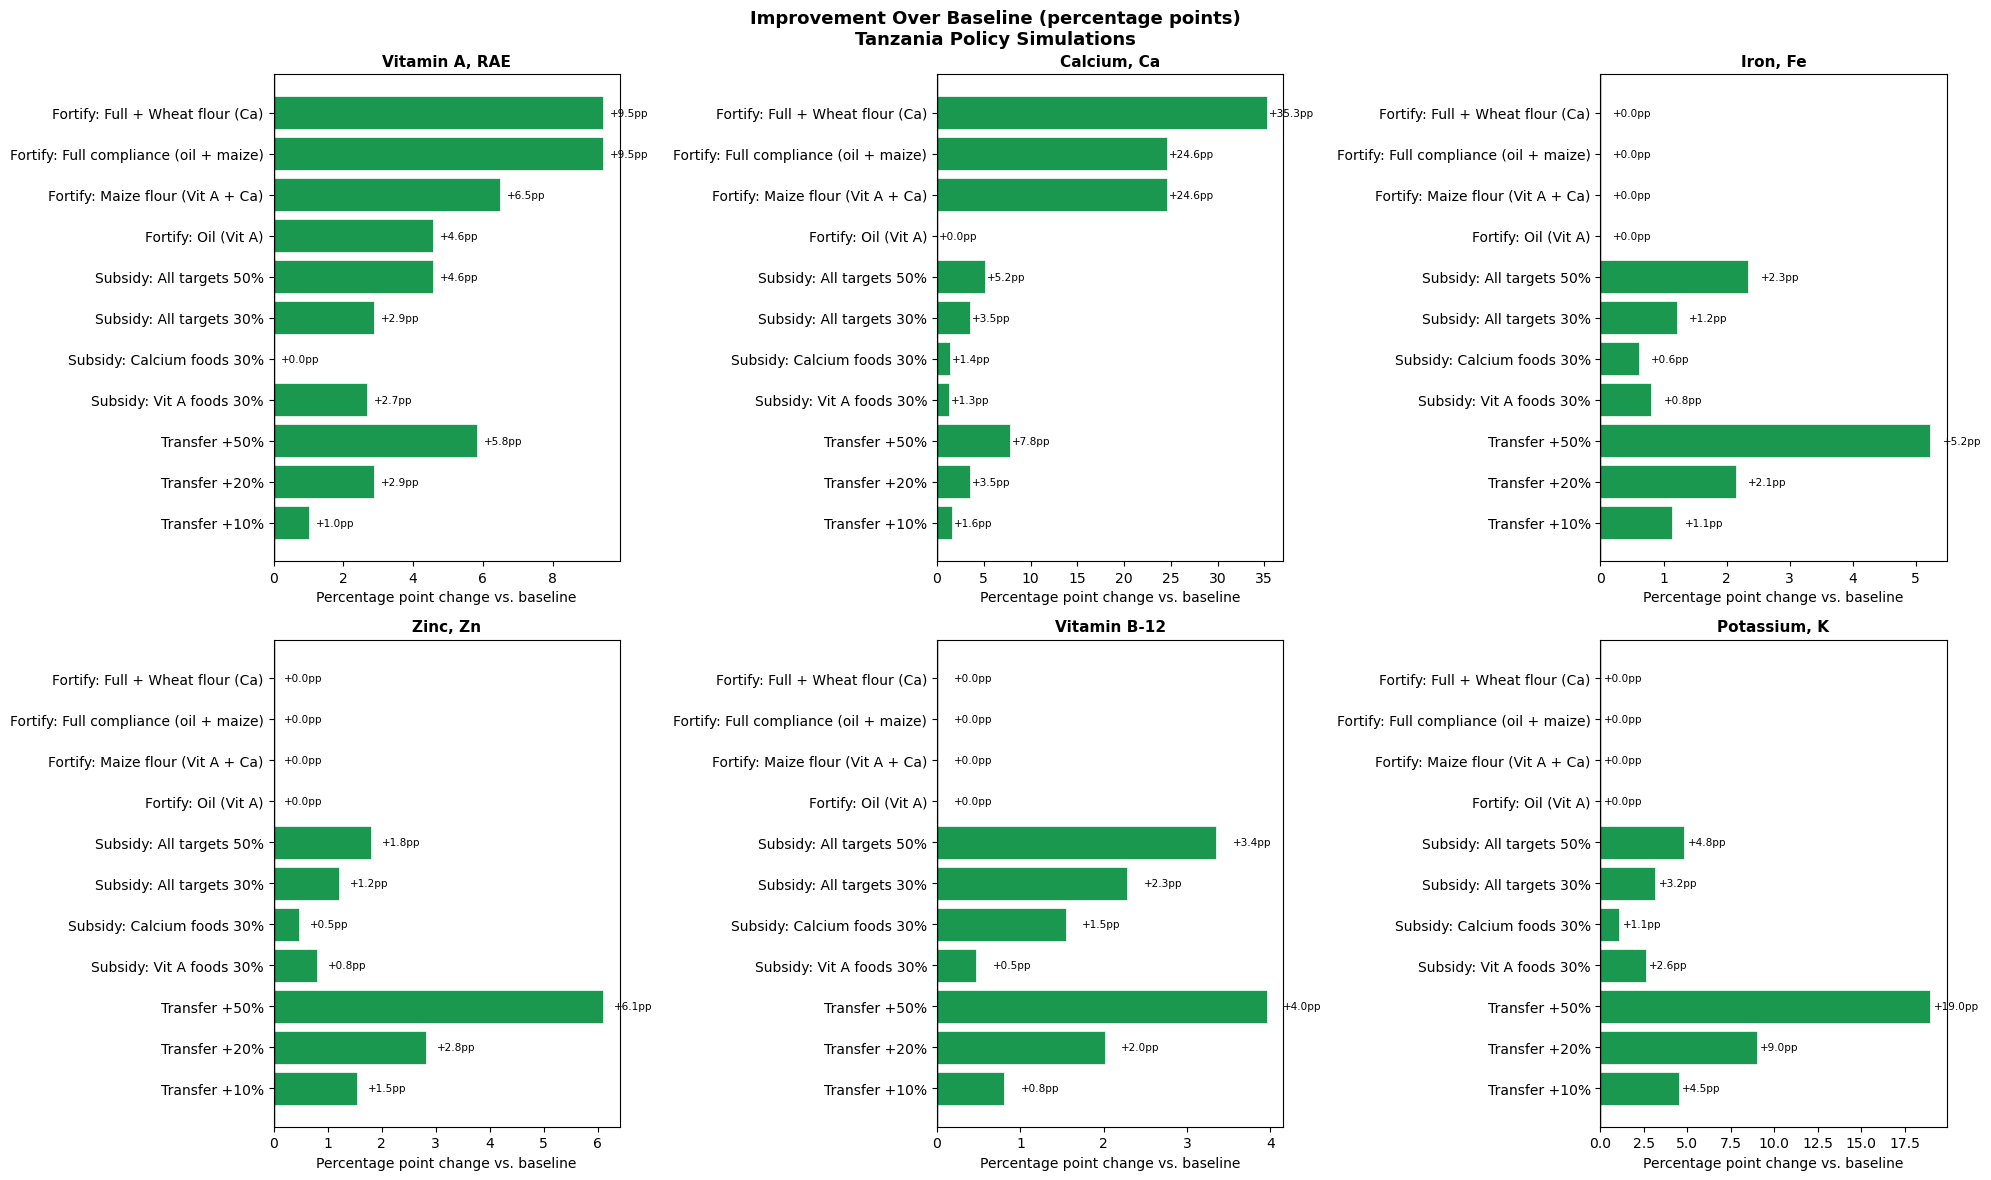

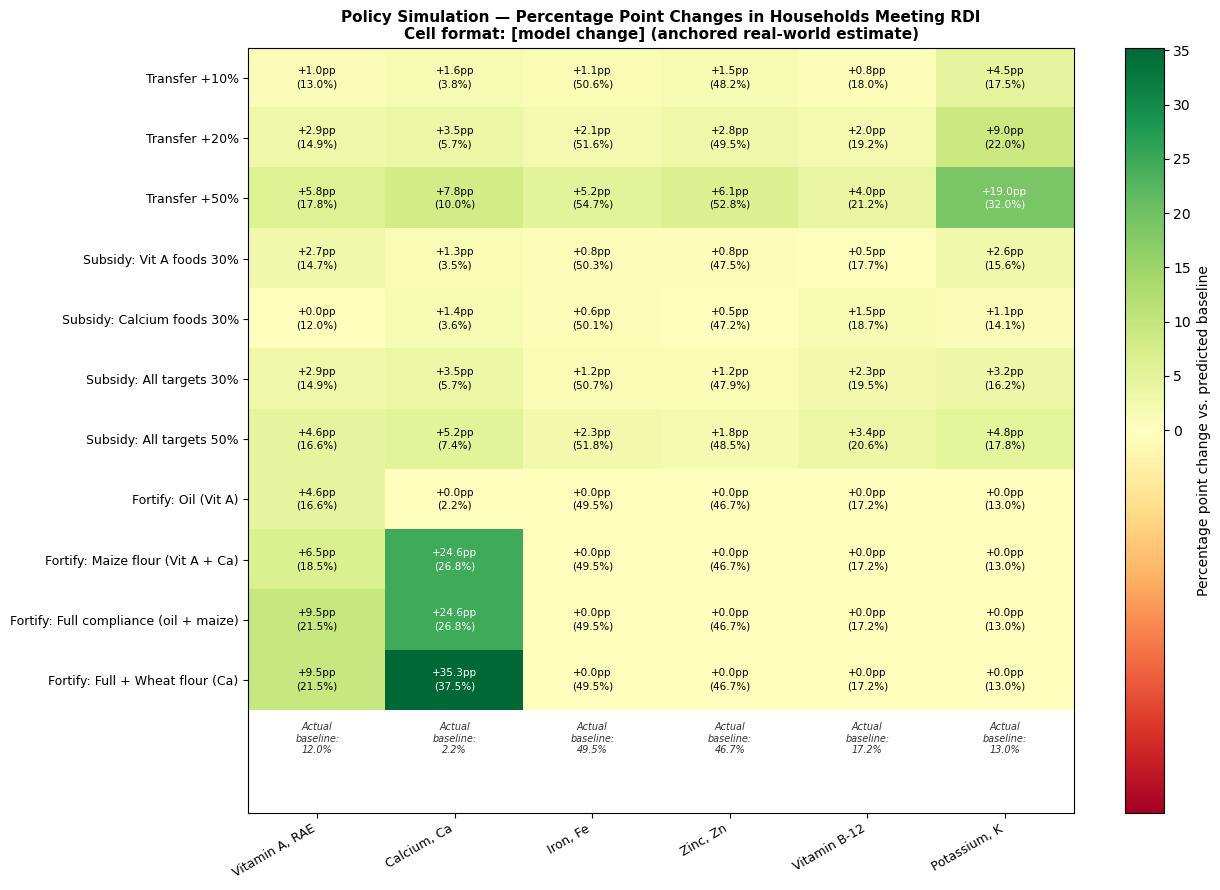

In [35]:
# Rebuild all_summary from simulation results dictionaries
all_results = {}
all_results['Baseline'] = baseline_pct
all_results.update({k: v for k, v in income_results.items() if k != 'Baseline'})
all_results.update({k: v for k, v in subsidy_results.items() if k != 'Baseline'})
all_results.update({k: v for k, v in fortification_results.items() if k != 'Baseline'})

all_summary = pd.DataFrame(all_results).T[TARGET_NUTRIENTS]

gains_table = (all_summary - all_summary.loc['Baseline']).drop('Baseline')

import matplotlib.patches as mpatches

# ── Figure 1: Policy comparison bar chart per nutrient ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

POLICY_COLORS = {
    'Baseline':                               '#888888',
    'Transfer +10%':                          '#b3cde3',
    'Transfer +20%':                          '#6baed6',
    'Transfer +50%':                          '#2171b5',
    'Subsidy: Vit A foods 30%':               '#fed976',
    'Subsidy: Calcium foods 30%':             '#fd8d3c',
    'Subsidy: All targets 30%':               '#e31a1c',
    'Subsidy: All targets 50%':               '#800026',
    'Fortify: Oil (Vit A)':                   '#c7e9c0',
    'Fortify: Maize flour (Vit A + Ca)':      '#74c476',
    'Fortify: Full compliance (oil + maize)': '#238b45',
    'Fortify: Full + Wheat flour (Ca)':       '#00441b',
}

for ax, nut in zip(axes, TARGET_NUTRIENTS):
    vals   = all_summary[nut]
    colors = [POLICY_COLORS.get(k, '#cccccc') for k in vals.index]
    bars   = ax.barh(vals.index, vals.values, color=colors,
                     edgecolor='white', linewidth=0.5)
    ax.axvline(vals['Baseline'], color='black', linewidth=1.2,
               linestyle='--', alpha=0.6)
    ax.set_title(nut, fontsize=11, fontweight='bold')
    ax.set_xlabel('% of households meeting RDI')
    ax.set_xlim(0, 100)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=7.5)

# Hide the unused 6th panel if TARGET_NUTRIENTS has fewer than 6 entries
for i in range(len(TARGET_NUTRIENTS), len(axes)):
    axes[i].set_visible(False)

legend_patches = [
    mpatches.Patch(color='#888888', label='Baseline'),
    mpatches.Patch(color='#6baed6', label='Income transfer (blue shades)'),
    mpatches.Patch(color='#e31a1c', label='Price subsidy (red/orange shades)'),
    mpatches.Patch(color='#238b45', label='Fortification (green shades)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    'Policy Simulation Results — % of Households Meeting Nutrient RDI\nTanzania Household Sample',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('tanzania_policy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Improvement over baseline (percentage point gains) ──────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(20, 12))
axes2 = axes2.flatten()

for ax, nut in zip(axes2, TARGET_NUTRIENTS):
    gains  = all_summary[nut] - all_summary.loc['Baseline', nut]
    gains  = gains.drop('Baseline')
    colors = ['#d73027' if g < 0 else '#1a9850' for g in gains]
    bars   = ax.barh(gains.index, gains.values, color=colors,
                     edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(nut, fontsize=11, fontweight='bold')
    ax.set_xlabel('Percentage point change vs. baseline')
    for bar, val in zip(bars, gains.values):
        xpos = val + 0.2 if val >= 0 else val - 0.2
        ha   = 'left'    if val >= 0 else 'right'
        ax.text(xpos, bar.get_y() + bar.get_height() / 2,
                f'{val:+.1f}pp', va='center', ha=ha, fontsize=7.5)

for i in range(len(TARGET_NUTRIENTS), len(axes2)):
    axes2[i].set_visible(False)

fig2.suptitle(
    'Improvement Over Baseline (percentage points)\nTanzania Policy Simulations',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('tanzania_policy_gains.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Heatmap of percentage point changes over ACTUAL baseline ────────

# Actual expenditure baseline adequacy rates (from Chunk 9 output)
# These are the ground-truth adequacy rates from observed expenditures
actual_baseline = pd.Series({
    'Vitamin A, RAE':  12.0,
    'Calcium, Ca':      2.2,
    'Iron, Fe':        49.5,
    'Zinc, Zn':        46.7,
    'Vitamin B-12':    17.2,
    'Potassium, K':    13.0,
})

# Compute percentage point changes from predicted baseline for each scenario
# Then anchor those changes to the actual baseline
predicted_baseline_pct = all_summary.loc['Baseline', TARGET_NUTRIENTS]
pp_changes = all_summary[TARGET_NUTRIENTS].subtract(predicted_baseline_pct, axis=1)

# Drop the baseline row — its change is zero by definition
pp_changes = pp_changes.drop('Baseline')

# Anchored rates: actual baseline + model-estimated change
anchored = pp_changes.add(actual_baseline[TARGET_NUTRIENTS], axis=1).clip(upper=100)

fig3, ax3 = plt.subplots(figsize=(13, 9))

vmin_val = pp_changes.values.min()
vmax_val = pp_changes.values.max()
if vmin_val >= 0:
    vmin_val = -0.1
if vmax_val <= 0:
    vmax_val = 0.1

im = ax3.imshow(pp_changes.values, aspect='auto', cmap='RdYlGn',
                norm=mcolors.TwoSlopeNorm(vmin=vmin_val,
                                          vcenter=0,
                                          vmax=vmax_val))

ax3.set_xticks(range(len(TARGET_NUTRIENTS)))
ax3.set_xticklabels(TARGET_NUTRIENTS, rotation=30, ha='right', fontsize=9)
ax3.set_yticks(range(len(pp_changes)))
ax3.set_yticklabels(pp_changes.index, fontsize=9)

# Annotate each cell with: change value and anchored absolute rate
for i in range(len(pp_changes)):
    for j, nut in enumerate(TARGET_NUTRIENTS):
        delta    = pp_changes.iloc[i, j]
        anchored_val = anchored.iloc[i, j]
        # Top line: the pp change; bottom line: what that means in real terms
        cell_text = f'{delta:+.1f}pp\n({anchored_val:.1f}%)'
        brightness = abs(delta) / (pp_changes.values.max() + 1e-6)
        txt_color  = 'white' if brightness > 0.5 else 'black'
        ax3.text(j, i, cell_text, ha='center', va='center',
                 fontsize=7.5, color=txt_color, linespacing=1.4)

# Actual baseline as a reference row along the bottom
for j, nut in enumerate(TARGET_NUTRIENTS):
    ax3.text(j, len(pp_changes) - 0.3, f'Actual\nbaseline:\n{actual_baseline[nut]:.1f}%',
             ha='center', va='top', fontsize=7, color='#333333',
             style='italic', transform=ax3.transData)

ax3.set_ylim(len(pp_changes) + 1.2, -0.5)  # extend bottom to make room

plt.colorbar(im, ax=ax3, label='Percentage point change vs. predicted baseline')
ax3.set_title(
    'Policy Simulation — Percentage Point Changes in Households Meeting RDI\n'
    'Cell format: [model change] (anchored real-world estimate)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('tanzania_policy_heatmap_changes.png', dpi=150, bbox_inches='tight')
plt.show()

### Policy Cost Analysis

In [36]:
# ── Cost analysis constants ───────────────────────────────────────────────────

TZS_PER_USD       = 2300       # approximate 2020 exchange rate
RECALL_DAYS       = 7          # survey recall period in days
WEEKS_PER_YEAR    = 52

# Tanzania population and household statistics (World Bank / NBS Tanzania 2020)
TZ_POPULATION          = 59_734_000
AVG_HOUSEHOLD_SIZE     = 4.7
TZ_HOUSEHOLDS          = TZ_POPULATION / AVG_HOUSEHOLD_SIZE   # ~12.7 million HH

# Sample sizes per wave
N_SAMPLE = {
    '2019-20': 1110,
    '2020-21':  406,
    'pooled':  1516,
}

# Scaling factor: sample -> national population
SCALE_TO_NATIONAL = TZ_HOUSEHOLDS / N_SAMPLE['pooled']

# Fortification cost estimates from literature (USD per metric tonne of food)
# Sources: Flour Fortification Initiative, HarvestPlus, Copenhagen Consensus
FORTIFICATION_COST_PER_TONNE = {
    'Cooking Oil':   12.0,   # Vitamin A fortification (USD/tonne oil)
    'Maize (flour)': 0.95,   # Vitamin A + Iron + Folate (USD/tonne flour)
    'Wheat Flour':   1.20,   # Calcium + Iron (USD/tonne flour)
}

def tzs_to_usd(tzs):
    return tzs / TZS_PER_USD

def usd_millions(usd):
    return usd / 1_000_000

def print_cost(label, annual_usd):
    print(f"  {label:<45} ${annual_usd/1e6:>8.2f}M USD/year")

In [37]:
# ── Policy 1 cost: Cash transfer ──────────────────────────────────────────────
# Transfer amount = X% of median weekly household food expenditure
# Cost = transfer per HH per week * 52 weeks * number of target households
#
# We consider two targeting strategies:
#   (a) Universal: all households receive the transfer
#   (b) Targeted:  bottom 40% of the expenditure distribution only

median_weekly_exp_tzs = 40_088   # from data above

print("=== POLICY 1: CASH TRANSFER COST ANALYSIS ===\n")

for transfer_pct, delta_w in [('10%', np.log(1.10)),
                                ('20%', np.log(1.20)),
                                ('50%', np.log(1.50))]:

    transfer_per_hh_week_tzs = median_weekly_exp_tzs * (np.exp(delta_w) - 1)
    transfer_per_hh_year_tzs = transfer_per_hh_week_tzs * WEEKS_PER_YEAR
    transfer_per_hh_year_usd = tzs_to_usd(transfer_per_hh_year_tzs)

    # Universal cost
    universal_cost_usd = transfer_per_hh_year_usd * TZ_HOUSEHOLDS
    # Targeted cost (bottom 40%)
    targeted_hh        = TZ_HOUSEHOLDS * 0.40
    targeted_cost_usd  = transfer_per_hh_year_usd * targeted_hh

    print(f"  Transfer size: {transfer_pct} income increase")
    print(f"    Transfer per HH per week : {transfer_per_hh_week_tzs:>10,.0f} TZS  "
          f"(${tzs_to_usd(transfer_per_hh_week_tzs):>6.2f} USD)")
    print(f"    Transfer per HH per year : {transfer_per_hh_year_tzs:>10,.0f} TZS  "
          f"(${transfer_per_hh_year_usd:>6.2f} USD)")
    print_cost('Universal annual cost', universal_cost_usd)
    print_cost('Targeted (bottom 40%) annual cost', targeted_cost_usd)
    print()

# Deadweight loss estimate
# DWL from cash transfer is minimal relative to in-kind transfers
# since cash preserves consumer choice — no allocative distortion
# DWL here is primarily administrative cost (~10-15% of transfer value,
# typical for Sub-Saharan Africa conditional cash transfer programs)
admin_rate = 0.12
transfer_20pct_universal = tzs_to_usd(median_weekly_exp_tzs * (np.exp(np.log(1.20))-1) * WEEKS_PER_YEAR) * TZ_HOUSEHOLDS
print(f"  Administrative cost (12% of transfer, universal 20%): "
      f"${admin_rate * transfer_20pct_universal / 1e6:.2f}M USD/year")

=== POLICY 1: CASH TRANSFER COST ANALYSIS ===

  Transfer size: 10% income increase
    Transfer per HH per week :      4,009 TZS  ($  1.74 USD)
    Transfer per HH per year :    208,458 TZS  ($ 90.63 USD)
  Universal annual cost                         $ 1151.90M USD/year
  Targeted (bottom 40%) annual cost             $  460.76M USD/year

  Transfer size: 20% income increase
    Transfer per HH per week :      8,018 TZS  ($  3.49 USD)
    Transfer per HH per year :    416,915 TZS  ($181.27 USD)
  Universal annual cost                         $ 2303.79M USD/year
  Targeted (bottom 40%) annual cost             $  921.52M USD/year

  Transfer size: 50% income increase
    Transfer per HH per week :     20,044 TZS  ($  8.71 USD)
    Transfer per HH per year :  1,042,288 TZS  ($453.17 USD)
  Universal annual cost                         $ 5759.48M USD/year
  Targeted (bottom 40%) annual cost             $ 2303.79M USD/year

  Administrative cost (12% of transfer, universal 20%): $276.46M 

In [38]:
# ── Policy 2 cost: Price subsidy ──────────────────────────────────────────────
# Cost = subsidy rate * price * quantity consumed nationally
# Quantity consumed = sample quantity * scale factor
#
# Deadweight loss (DWL) from a per-unit subsidy:
# DWL = 0.5 * |elasticity| * (subsidy_per_unit)^2 * (dQ/dP)
# Simplified: DWL ≈ 0.5 * subsidy_rate^2 * total_expenditure * |own_price_elasticity|

OWN_PRICE_ELASTICITY = -0.5

# Weekly expenditure on each subsidy food in the sample (from data above)
sample_weekly_exp = {
    'Sweet Potatoes': 1_601_154,
    'Leafy Greens':   2_158_611,
    'Eggs':             645_327,
    'Fish (dried)':   1_603_318,
    'Bread':          1_088_151,
    'Milk (fresh)':   1_591_158,
}

SUBSIDY_SCENARIOS_COSTS = {
    'Subsidy: Vit A foods 30%':   (['Sweet Potatoes','Leafy Greens','Eggs'], 0.30),
    'Subsidy: Calcium foods 30%': (['Fish (dried)','Bread','Milk (fresh)'],  0.30),
    'Subsidy: All targets 30%':   (list(sample_weekly_exp.keys()),           0.30),
    'Subsidy: All targets 50%':   (list(sample_weekly_exp.keys()),           0.50),
}

print("=== POLICY 2: PRICE SUBSIDY COST ANALYSIS ===\n")

for label, (foods, rate) in SUBSIDY_SCENARIOS_COSTS.items():
    # Total weekly sample expenditure on subsidised foods
    sample_weekly = sum(sample_weekly_exp[f] for f in foods)

    # Scale to national, annualise
    national_annual_exp_tzs = sample_weekly * SCALE_TO_NATIONAL * WEEKS_PER_YEAR
    national_annual_exp_usd = tzs_to_usd(national_annual_exp_tzs)

    # Government subsidy cost = rate * pre-subsidy expenditure
    # (quantity increases, but government pays the price gap on ALL units consumed)
    # Adjusted for quantity increase due to subsidy
    quantity_increase_factor = 1 + abs(OWN_PRICE_ELASTICITY) * rate
    subsidy_cost_usd = rate * national_annual_exp_usd * quantity_increase_factor

    # Deadweight loss triangle
    # DWL = 0.5 * subsidy_rate * quantity_change * price_change
    # = 0.5 * rate^2 * |elasticity| * national_expenditure
    dwl_usd = 0.5 * (rate ** 2) * abs(OWN_PRICE_ELASTICITY) * national_annual_exp_usd

    print(f"  {label}")
    print_cost('Government subsidy cost', subsidy_cost_usd)
    print_cost('Deadweight loss (efficiency cost)', dwl_usd)
    print(f"    DWL as % of subsidy cost: {dwl_usd/subsidy_cost_usd*100:.1f}%")
    print()

=== POLICY 2: PRICE SUBSIDY COST ANALYSIS ===

  Subsidy: Vit A foods 30%
  Government subsidy cost                       $  288.05M USD/year
  Deadweight loss (efficiency cost)             $   18.79M USD/year
    DWL as % of subsidy cost: 6.5%

  Subsidy: Calcium foods 30%
  Government subsidy cost                       $  280.05M USD/year
  Deadweight loss (efficiency cost)             $   18.26M USD/year
    DWL as % of subsidy cost: 6.5%

  Subsidy: All targets 30%
  Government subsidy cost                       $  568.10M USD/year
  Deadweight loss (efficiency cost)             $   37.05M USD/year
    DWL as % of subsidy cost: 6.5%

  Subsidy: All targets 50%
  Government subsidy cost                       $ 1029.17M USD/year
  Deadweight loss (efficiency cost)             $  102.92M USD/year
    DWL as % of subsidy cost: 10.0%



In [40]:
# ── Policy 3 cost: Fortification ─────────────────────────────────────────────
# Cost = (cost per tonne of fortification) * (annual tonnes consumed nationally)
# Fortification has near-zero DWL since it does not distort relative prices —
# it shifts the nutrient content of a good without changing its market price.
# The cost is borne by producers and typically passed through as a small
# price increase (~1-3%), which we treat as negligible here.

# Annual national consumption in tonnes
# Derived from: sample weekly expenditure / price per kg * scale * 52 / 1000

national_price_per_kg = {
    'Cooking Oil':  3993,
    'Maize (flour)': 1245,
    'Wheat Flour':   1455,
}

# Weekly expenditure in sample on these foods
sample_weekly_exp_fort = {}
x_all = pd.concat([
    pd.read_excel('Tanzania.xlsx', sheet_name='Food Expenditures (2019-20)'),
    pd.read_excel('Tanzania.xlsx', sheet_name='Food Expenditures (2020-21)')
])
for food in ['Cooking Oil', 'Maize (flour)', 'Wheat Flour']:
    sample_weekly_exp_fort[food] = x_all[x_all['j'] == food]['Expenditure'].sum()

print("=== POLICY 3: FORTIFICATION COST ANALYSIS ===\n")
print("  Annual national consumption estimates:")

annual_tonnes = {}
for food, price_kg in national_price_per_kg.items():
    weekly_kg_sample = sample_weekly_exp_fort[food] / price_kg
    annual_tonnes[food] = weekly_kg_sample * SCALE_TO_NATIONAL * WEEKS_PER_YEAR / 1000
    print(f"    {food:<20} {annual_tonnes[food]:>10,.0f} tonnes/year")

print()

fort_scenarios = {
    'Fortify: Oil (Vit A)': ['Cooking Oil'],
    'Fortify: Maize flour (Vit A + Ca)': ['Maize (flour)'],
    'Fortify: Full compliance (oil + maize)': ['Cooking Oil', 'Maize (flour)'],
    'Fortify: Full + Wheat flour (Ca)': ['Cooking Oil', 'Maize (flour)', 'Wheat Flour'],
}

for label, foods in fort_scenarios.items():
    total_cost_usd = sum(
        annual_tonnes[f] * FORTIFICATION_COST_PER_TONNE[f]
        for f in foods
    )
    print(f"  {label}")
    print_cost('Annual fortification cost', total_cost_usd)
    print(f"    Cost per tonne: "
          + ", ".join(f"{f} ${FORTIFICATION_COST_PER_TONNE[f]:.2f}/t" for f in foods))
    # No DWL from fortification — note this explicitly
    print(f"    Deadweight loss: ~$0 (no price distortion)")
    print()

=== POLICY 3: FORTIFICATION COST ANALYSIS ===

  Annual national consumption estimates:
    Cooking Oil             719,694 tonnes/year
    Maize (flour)         3,709,043 tonnes/year
    Wheat Flour             243,565 tonnes/year

  Fortify: Oil (Vit A)
  Annual fortification cost                     $    8.64M USD/year
    Cost per tonne: Cooking Oil $12.00/t
    Deadweight loss: ~$0 (no price distortion)

  Fortify: Maize flour (Vit A + Ca)
  Annual fortification cost                     $    3.52M USD/year
    Cost per tonne: Maize (flour) $0.95/t
    Deadweight loss: ~$0 (no price distortion)

  Fortify: Full compliance (oil + maize)
  Annual fortification cost                     $   12.16M USD/year
    Cost per tonne: Cooking Oil $12.00/t, Maize (flour) $0.95/t
    Deadweight loss: ~$0 (no price distortion)

  Fortify: Full + Wheat flour (Ca)
  Annual fortification cost                     $   12.45M USD/year
    Cost per tonne: Cooking Oil $12.00/t, Maize (flour) $0.95/t, Whea

=== COST-EFFECTIVENESS SUMMARY ===

Scenario                         Cost ($M/yr)  Avg pp gain   Cost/pp ($M)
--------------------------------------------------------------------------
Transfer +20% (Universal)             2303.79         3.72         619.33
Transfer +20% (Targeted 40%)           921.52         3.72         247.73
Subsidy: Vit A foods 30%               288.05         1.44         199.89
Subsidy: Calcium foods 30%             280.05         0.85         329.87
Subsidy: All targets 30%               568.10         2.37         239.89
Subsidy: All targets 50%              1029.17         3.68         280.03
Fortify: Oil (Vit A)                     8.64         0.76          11.37
Fortify: Maize (Vit A + Ca)              3.52         5.18           0.68
Fortify: Full compliance                12.16         5.67           2.14
Fortify: Full + Wheat Ca                12.45         7.45           1.67


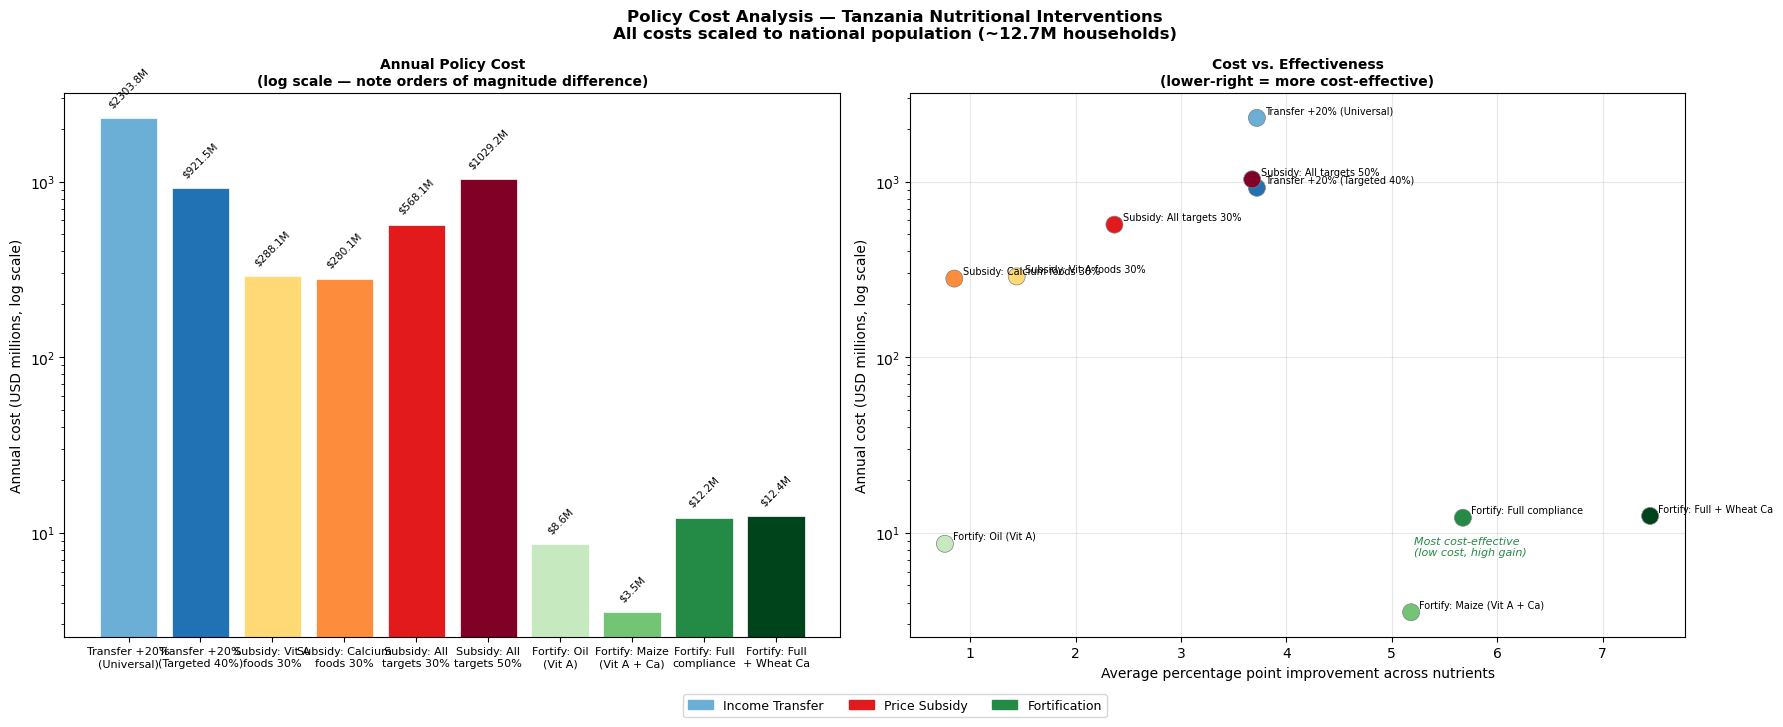

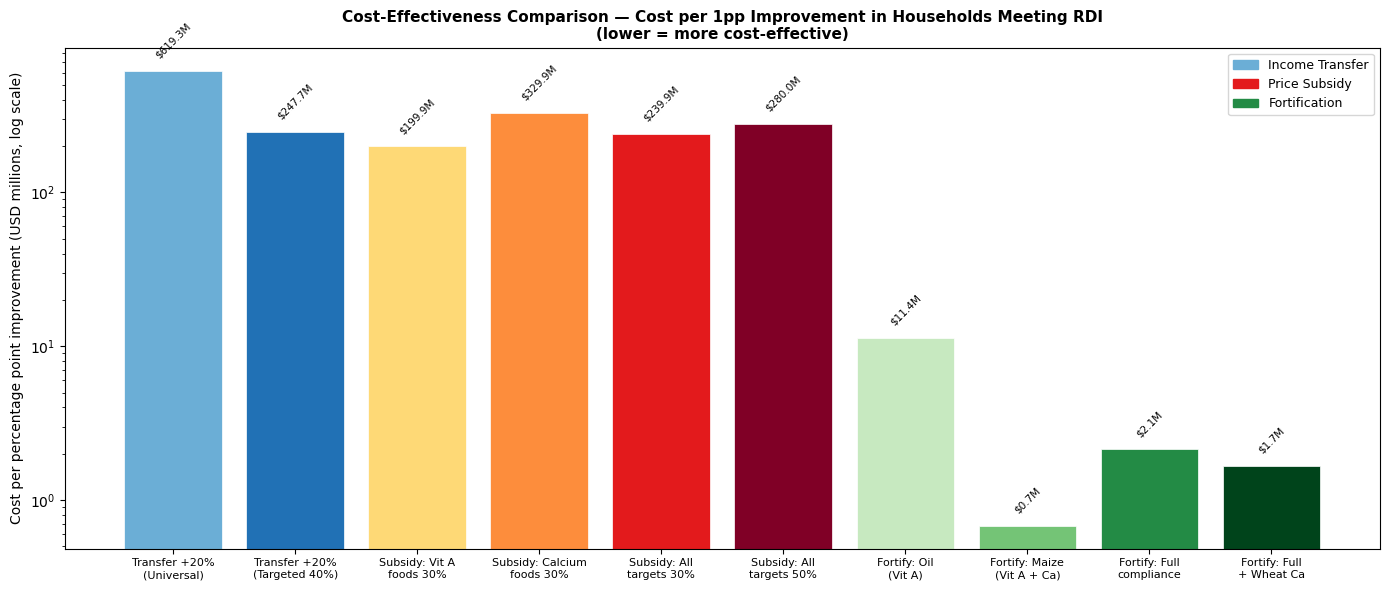

In [41]:
# ── Cost-effectiveness summary and visualization ──────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Costs from Chunks 18-20 outputs ──────────────────────────────────────────
ce_data = {
    'Transfer +20%\n(Universal)': {
        'annual_cost_usd_m': 2303.79,
        'pp_gains':          gains_table.loc['Transfer +20%', TARGET_NUTRIENTS].mean(),
        'color':             '#6baed6',
        'type':              'Income Transfer',
    },
    'Transfer +20%\n(Targeted 40%)': {
        'annual_cost_usd_m': 921.52,
        'pp_gains':          gains_table.loc['Transfer +20%', TARGET_NUTRIENTS].mean(),
        'color':             '#2171b5',
        'type':              'Income Transfer',
    },
    'Subsidy: Vit A\nfoods 30%': {
        'annual_cost_usd_m': 288.05,
        'pp_gains':          gains_table.loc['Subsidy: Vit A foods 30%', TARGET_NUTRIENTS].mean(),
        'color':             '#fed976',
        'type':              'Price Subsidy',
    },
    'Subsidy: Calcium\nfoods 30%': {
        'annual_cost_usd_m': 280.05,
        'pp_gains':          gains_table.loc['Subsidy: Calcium foods 30%', TARGET_NUTRIENTS].mean(),
        'color':             '#fd8d3c',
        'type':              'Price Subsidy',
    },
    'Subsidy: All\ntargets 30%': {
        'annual_cost_usd_m': 568.10,
        'pp_gains':          gains_table.loc['Subsidy: All targets 30%', TARGET_NUTRIENTS].mean(),
        'color':             '#e31a1c',
        'type':              'Price Subsidy',
    },
    'Subsidy: All\ntargets 50%': {
        'annual_cost_usd_m': 1029.17,
        'pp_gains':          gains_table.loc['Subsidy: All targets 50%', TARGET_NUTRIENTS].mean(),
        'color':             '#800026',
        'type':              'Price Subsidy',
    },
    'Fortify: Oil\n(Vit A)': {
        'annual_cost_usd_m': 8.64,
        'pp_gains':          gains_table.loc['Fortify: Oil (Vit A)', TARGET_NUTRIENTS].mean(),
        'color':             '#c7e9c0',
        'type':              'Fortification',
    },
    'Fortify: Maize\n(Vit A + Ca)': {
        'annual_cost_usd_m': 3.52,
        'pp_gains':          gains_table.loc['Fortify: Maize flour (Vit A + Ca)', TARGET_NUTRIENTS].mean(),
        'color':             '#74c476',
        'type':              'Fortification',
    },
    'Fortify: Full\ncompliance': {
        'annual_cost_usd_m': 12.16,
        'pp_gains':          gains_table.loc['Fortify: Full compliance (oil + maize)', TARGET_NUTRIENTS].mean(),
        'color':             '#238b45',
        'type':              'Fortification',
    },
    'Fortify: Full\n+ Wheat Ca': {
        'annual_cost_usd_m': 12.45,
        'pp_gains':          gains_table.loc['Fortify: Full + Wheat flour (Ca)', TARGET_NUTRIENTS].mean(),
        'color':             '#00441b',
        'type':              'Fortification',
    },
}

scenarios    = list(ce_data.keys())
costs        = [ce_data[s]['annual_cost_usd_m'] for s in scenarios]
pp_gains_all = [ce_data[s]['pp_gains'] for s in scenarios]
colors_bars  = [ce_data[s]['color'] for s in scenarios]
cost_per_pp  = [c / pp if pp > 0 else np.nan
                for c, pp in zip(costs, pp_gains_all)]

# ── Print cost-effectiveness table ───────────────────────────────────────────
print("=== COST-EFFECTIVENESS SUMMARY ===\n")
print(f"{'Scenario':<30} {'Cost ($M/yr)':>14} {'Avg pp gain':>12} {'Cost/pp ($M)':>14}")
print('-' * 74)
for s, c, pp, cpp in zip(scenarios, costs, pp_gains_all, cost_per_pp):
    s_clean = s.replace('\n', ' ')
    print(f"{s_clean:<30} {c:>14.2f} {pp:>12.2f} {cpp:>14.2f}")

# ── Figure 1: Cost and pp gain side by side ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: annual cost bar chart (log scale given the huge range)
bars = axes[0].bar(range(len(scenarios)), costs, color=colors_bars,
                   edgecolor='white', linewidth=0.5)
axes[0].set_yscale('log')
axes[0].set_xticks(range(len(scenarios)))
axes[0].set_xticklabels(scenarios, fontsize=8)
axes[0].set_ylabel('Annual cost (USD millions, log scale)')
axes[0].set_title('Annual Policy Cost\n(log scale — note orders of magnitude difference)',
                  fontsize=10, fontweight='bold')
for bar, c in zip(bars, costs):
    axes[0].text(bar.get_x() + bar.get_width()/2, c * 1.15,
                 f'${c:.1f}M', ha='center', fontsize=7.5, rotation=45)

# Right: cost per percentage point improvement scatter
sc = axes[1].scatter(pp_gains_all, costs, c=colors_bars, s=150,
                     zorder=3, edgecolors='grey', linewidths=0.5)
for s, c, pp in zip(scenarios, costs, pp_gains_all):
    axes[1].annotate(s.replace('\n', ' '), (pp, c),
                     textcoords='offset points', xytext=(6, 3), fontsize=7)
axes[1].set_yscale('log')
axes[1].set_xlabel('Average percentage point improvement across nutrients', fontsize=10)
axes[1].set_ylabel('Annual cost (USD millions, log scale)', fontsize=10)
axes[1].set_title('Cost vs. Effectiveness\n(lower-right = more cost-effective)',
                  fontsize=10, fontweight='bold')
axes[1].grid(alpha=0.3)
# Annotate the cost-effectiveness frontier
axes[1].annotate('Most cost-effective\n(low cost, high gain)',
                 xy=(0.65, 0.15), xycoords='axes fraction',
                 fontsize=8, color='#238b45', style='italic')

legend_patches = [
    mpatches.Patch(color='#6baed6', label='Income Transfer'),
    mpatches.Patch(color='#e31a1c', label='Price Subsidy'),
    mpatches.Patch(color='#238b45', label='Fortification'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Policy Cost Analysis — Tanzania Nutritional Interventions\n'
             'All costs scaled to national population (~12.7M households)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('tanzania_policy_costs.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Cost per pp improvement bar chart ───────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 6))
bars2 = ax2.bar(range(len(scenarios)), cost_per_pp, color=colors_bars,
                edgecolor='white', linewidth=0.5)
ax2.set_yscale('log')
ax2.set_xticks(range(len(scenarios)))
ax2.set_xticklabels(scenarios, fontsize=8)
ax2.set_ylabel('Cost per percentage point improvement (USD millions, log scale)')
ax2.set_title('Cost-Effectiveness Comparison — Cost per 1pp Improvement in Households Meeting RDI\n'
              '(lower = more cost-effective)', fontsize=11, fontweight='bold')
for bar, cpp in zip(bars2, cost_per_pp):
    ax2.text(bar.get_x() + bar.get_width()/2, cpp * 1.2,
             f'${cpp:.1f}M', ha='center', fontsize=7.5, rotation=45)
ax2.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig('tanzania_cost_per_pp.png', dpi=150, bbox_inches='tight')
plt.show()

The annual cost graph is on a log scale...meaning the actual difference in costs between the fortification policies and the rest are enormous. Without the log scale, the fortification bars would be basically invisible because of this difference ($3-12M vs $280-2300M). This is probably our most important finding: fortification of maize flour at $3.52M/year is roughly 80–650x cheaper than any transfer or subsidy scenario for comparable nutritional gains.